In [1]:
import pandas as pd
from pathlib import Path
from typing import Dict, Union
import pysam
import numpy as np
import seaborn as sns
import os
import gzip
import matplotlib.pyplot as plt
import itertools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from adjustText import adjust_text
from statsmodels.stats.multitest import multipletests
from collections import defaultdict

import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

#Add arial font (ONLY ADD ONCE AT THE BEGINNING) - if you don't want to add arial font, just change the font family to something else
from matplotlib import font_manager
font_manager.fontManager.addfont("XXXXX/fonts/ARIAL.TTF")
font_manager.fontManager.addfont("XXXXX/fonts/ARIALBD.TTF")
font_manager.fontManager.addfont("XXXXX/fonts/ARIALBI.TTF")
font_manager.fontManager.addfont("XXXXX/fonts/ARIALI.TTF")
font_manager.fontManager.addfont("XXXXX/fonts/ARIALN.TTF")
font_manager.fontManager.addfont("XXXXX/fonts/ARIALNB.TTF")
font_manager.fontManager.addfont("XXXXX/fonts/ARIALNBI.TTF")
font_manager.fontManager.addfont("XXXXX/fonts/ARIALNI.TTF")
font_manager.fontManager.addfont("XXXXX/fonts/ARIBLK.TTF")

for f in font_manager.fontManager.ttflist:
    if "arial" in f.name.lower():
        print(f.name, "|", f.style, "|", f.weight)

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['axes.facecolor'] = 'white'


palette = {
    "Pmand": "#a2f0d9",
    "Stub": "#b0b0b0" 
}

Arial | normal | 400
Arial | normal | 700
Arial | italic | 700
Arial | italic | 400
Arial | normal | 400
Arial | normal | 700
Arial | italic | 700
Arial | italic | 400
Arial | normal | 900


In [2]:
import matplotlib
import scipy
import statsmodels
#os.system("python -m pip install seaborn==0.12.2")
#print("python verison: " + platform.python_version())
print("pandas version: " + pd.__version__)
print("pysam version: " + pysam.__version__)
print("seaborn version: " + sns.__version__)
print("numpy version: " + np.__version__)
print("matplotlib version: " + matplotlib.__version__)
print("scipy version: " + scipy.__version__) 
print("statsmodels version: " + statsmodels.__version__)

pandas version: 2.3.3
pysam version: 0.23.3
seaborn version: 0.12.2
numpy version: 1.26.4
matplotlib version: 3.9.2
scipy version: 1.13.1
statsmodels version: 0.14.6


# Figure 1

In [3]:
#CDF and change in CDF between mapping rates by condition
PathLike = Union[str, Path]

def read_lengths_from_bam(bam_path):
    lengths = []
    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for r in bam.fetch(until_eof=True):
            if not r.is_unmapped and r.query_length is not None:
                lengths.append(r.query_length)
    return np.array(lengths)


def build_all_tables(
    noadaptive_path: PathLike,
    stub_depleted_path: PathLike,
    pmand_enriched_path_1: PathLike,
    pmand_enriched_path_2: PathLike,
) -> Dict[str, pd.DataFrame]:

    no_df = group_single_summary(
        read_summary_with_barcode(noadaptive_path)
    )
    no_df.insert(0, "sample_group", "noAdaptive")

    stub_df = group_single_summary(
        read_summary_with_barcode(stub_depleted_path)
    )
    stub_df.insert(0, "sample_group", "Stub_depleted")

    p1 = read_summary_with_barcode(pmand_enriched_path_1)
    p2 = read_summary_with_barcode(pmand_enriched_path_2)
    pmand_df = merge_pmand_enriched(p1, p2)
    pmand_df.insert(0, "sample_group", "Pmand_enriched")

    return {
        "noAdaptive": no_df,
        "Stub_depleted": stub_df,
        "Pmand_enriched": pmand_df,
    }

def group_single_summary(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("barcode_group", as_index=False)
          .agg(
              reads=("reads", "sum"),
              Pmand_primary_mapped=("Pmand_primary_mapped", "sum"),
              Stub_primary_mapped=("Stub_primary_mapped", "sum"),
              min_length=("min_length", "min"),
              max_length=("max_length", "max"),
          )
    )

def read_summary_with_barcode(path: PathLike) -> pd.DataFrame:
    path = Path(path)
    df = pd.read_csv(path, sep="\t")

    if "barcode" not in df.columns:
        raise ValueError(f"'barcode' column missing in {path}")

    df["barcode_group"] = df["barcode"].astype(str).str.split("_").str[0]

    rename_map = {
        "fastq_reads": "reads",
        "min_read_len": "min_length",
        "max_read_len": "max_length",
        "Pmanda_primary_mapped": "Pmand_primary_mapped",
    }
    df = df.rename(columns=rename_map)

    needed = [
        "barcode_group",
        "reads",
        "min_length",
        "max_length",
        "Pmand_primary_mapped",
        "Stub_primary_mapped",
    ]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {path}: {missing}")

    df = df[needed].copy()

    for c in needed[1:]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


def merge_pmand_enriched(df1: pd.DataFrame, df2: pd.DataFrame) -> pd.DataFrame:
    combined = pd.concat([df1, df2], ignore_index=True)

    return (
        combined.groupby("barcode_group", as_index=False)
        .agg(
            reads=("reads", "sum"),
            Pmand_primary_mapped=("Pmand_primary_mapped", "sum"),
            Stub_primary_mapped=("Stub_primary_mapped", "sum"),
            min_length=("min_length", "min"),
            max_length=("max_length", "max"),
        )
    )

In [4]:
barcodes = [f"barcode0{i}" for i in range(1, 7)]

pmand_lengths = {}
stub_lengths  = {}

bam_dir = Path("XXXXX/AdaptiveSequencing/Align_IK82/NoAdaptive/MinLength1/bam")
tables = build_all_tables(
    "XXXXX/AdaptiveSequencing/Align_IK82/NoAdaptive/MinLength1/summary.tsv",
    "XXXXX/AdaptiveSequencing/Align_IK82/Stub_depleted/MinLength1/summary.tsv",
    "XXXXX/AdaptiveSequencing/Align_IK82/Pmand_enriched/Pool1/MinLength1/summary.tsv",
    "XXXXX/AdaptiveSequencing/Align_IK82/Pmand_enriched/no_sample/MinLength1/summary.tsv",
)

for bc in barcodes:
    pmand_bams = sorted(bam_dir.glob(f"{bc}_*.Pmanda.sorted.bam"))
    stub_bams  = sorted(bam_dir.glob(f"{bc}_*.Stub.sorted.bam"))

    if len(pmand_bams) == 0:
        print(f"WARNING: no Pmand BAMs found for {bc}")
    if len(stub_bams) == 0:
        print(f"WARNING: no Stub BAMs found for {bc}")

    pmand_lengths[bc] = np.concatenate([read_lengths_from_bam(bam) for bam in pmand_bams]) if pmand_bams else np.array([])

    stub_lengths[bc] = np.concatenate([read_lengths_from_bam(bam) for bam in stub_bams]) if stub_bams else np.array([])



In [5]:
no_adaptive_bam_dir = Path("XXXXX/AdaptiveSequencing/Align_IK82/NoAdaptive/MinLength1/bam")
deplete_bam_dir     = Path("XXXXX/AdaptiveSequencing/Align_IK82/Stub_depleted/MinLength1/bam")

#enrichment was run with a wash in the middle, so it produced two libraries 
enrich_bam_dirs     = [
    Path("XXXXX/AdaptiveSequencing/Align_IK82/Pmand_enriched/Pool1/MinLength1/bam"),
    Path("XXXXX/AdaptiveSequencing/Align_IK82/Pmand_enriched/no_sample/MinLength1/bam"),
]

barcodes = [f"barcode0{i}" for i in range(1, 7)] 

PMAND_SUFFIX = ".Pmanda.sorted.bam"
STUB_SUFFIX  = ".Stub.sorted.bam"

def clean(a):
    a = np.asarray(a)
    return a[a > 0]

def concat_read_lengths_from_bams(bam_paths):
    if not bam_paths:
        return np.array([], dtype=int)
    return np.concatenate([read_lengths_from_bam(b) for b in bam_paths])

def collect_bams(bam_dirs, pattern):
    if isinstance(bam_dirs, (str, Path)):
        bam_dirs = [Path(bam_dirs)]
    out = []
    for d in bam_dirs:
        out.extend(sorted(d.glob(pattern)))
    return out

#output lengths of all reads by type
pmand_lengths = {c: {} for c in ["no_adaptive", "deplete", "enrich"]}
stub_lengths  = {c: {} for c in ["no_adaptive", "deplete", "enrich"]}

for bc in barcodes:
    # no adaptive
    pmand_bams = collect_bams(no_adaptive_bam_dir, f"{bc}_*{PMAND_SUFFIX}")
    stub_bams  = collect_bams(no_adaptive_bam_dir, f"{bc}_*{STUB_SUFFIX}")
    pmand_lengths["no_adaptive"][bc] = clean(concat_read_lengths_from_bams(pmand_bams))
    stub_lengths["no_adaptive"][bc]  = clean(concat_read_lengths_from_bams(stub_bams))

    # host depletion
    pmand_bams = collect_bams(deplete_bam_dir, f"{bc}_*{PMAND_SUFFIX}")
    stub_bams  = collect_bams(deplete_bam_dir, f"{bc}_*{STUB_SUFFIX}")
    pmand_lengths["deplete"][bc] = clean(concat_read_lengths_from_bams(pmand_bams))
    stub_lengths["deplete"][bc]  = clean(concat_read_lengths_from_bams(stub_bams))

    # symbiont enrichment
    pmand_bams = collect_bams(enrich_bam_dirs, f"{bc}_*{PMAND_SUFFIX}")
    stub_bams  = collect_bams(enrich_bam_dirs, f"{bc}_*{STUB_SUFFIX}")
    pmand_lengths["enrich"][bc] = clean(concat_read_lengths_from_bams(pmand_bams))
    stub_lengths["enrich"][bc]  = clean(concat_read_lengths_from_bams(stub_bams))

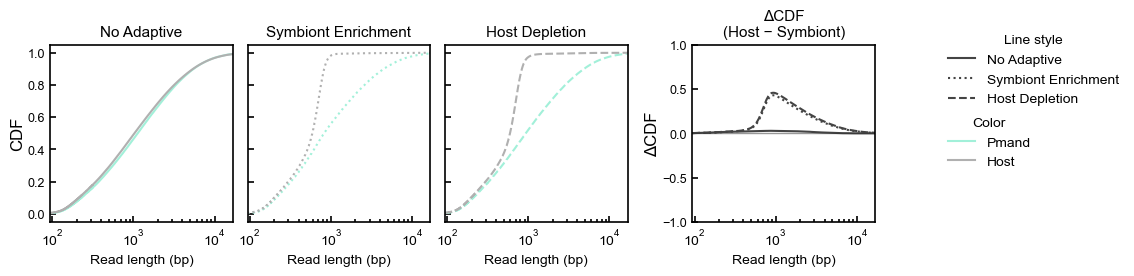

In [6]:
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
})

def compute_cdf(arr):
    arr = np.sort(arr)
    cdf = np.arange(1, len(arr) + 1) / len(arr)
    return arr, cdf

def ecdf_on_grid(arr, xgrid):
    s = np.sort(arr)
    return np.searchsorted(s, xgrid, side="right") / len(s)

def pooled_lengths(length_dict, cond):
    arrs = [
        np.asarray(length_dict[cond][bc])
        for bc in barcodes
        if len(length_dict[cond][bc]) > 0
    ]
    if not arrs:
        return np.array([], dtype=float)
    out = np.concatenate(arrs)
    return out[np.isfinite(out) & (out > 0)]

#plotting style/formatting
cond_order = ["no_adaptive", "enrich", "deplete"]

cond_titles = {
    "no_adaptive": "No Adaptive",
    "deplete": "Host Depletion",
    "enrich": "Symbiont Enrichment",
    "delta": "ΔCDF\n(Host − Symbiont)",
}

linestyles = {
    "no_adaptive": "-",
    "enrich": ":",
    "deplete": "--",
}

col_conds = ["no_adaptive", "enrich", "deplete"]
col_titles = [cond_titles[c] for c in col_conds] + [cond_titles["delta"]]

#pool barcodes by sequencing type
pooled_pmand = {cond: pooled_lengths(pmand_lengths, cond) for cond in cond_order}
pooled_stub  = {cond: pooled_lengths(stub_lengths, cond)  for cond in cond_order}

#Plotting
all_lengths = []
for cond in cond_order:
    if len(pooled_pmand[cond]) > 0:
        all_lengths.append(pooled_pmand[cond])
    if len(pooled_stub[cond]) > 0:
        all_lengths.append(pooled_stub[cond])

all_lengths = np.concatenate(all_lengths)
all_lengths = all_lengths[np.isfinite(all_lengths) & (all_lengths > 0)]

xmin = max(float(np.percentile(all_lengths, 0.5)), 1.0)
xmax = float(np.percentile(all_lengths, 99.5))

#grid used for ΔCDF
xgrid = np.logspace(np.log10(xmin), np.log10(xmax), 400)

#Plot figure
fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(10, 2.3),
    sharex=False,
    sharey=False,
    gridspec_kw={"wspace": 0.08}
)

fig.patch.set_facecolor("white")

#pooled CDFs by barcode
for j, cond in enumerate(col_conds):
    ax = axes[j]

    a = pooled_pmand[cond]  
    b = pooled_stub[cond]   

    if len(a) > 0:
        xa, ya = compute_cdf(a)
        pd.DataFrame({"read_length_bp": xa,"cdf": ya,}).to_csv(f"XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1A_{cond}_Pmand_CDF_SourceData.csv",index=False)
        ax.plot(
            xa, ya,
            color=palette["Pmand"],
            linestyle=linestyles[cond],
            linewidth=1.5,
            label="Pmand"
        )
        
    else:
        ax.text(
            0.03, 0.92, "Pmand: 0",
            transform=ax.transAxes,
            color=palette["Pmand"],
            fontsize=8
        )

    if len(b) > 0:
        xb, yb = compute_cdf(b)
        pd.DataFrame({"read_length_bp": xb,"cdf": yb,}).to_csv(f"XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure 1A_{cond}_Host_CDF_SourceData.csv",index=False)
        ax.plot(
            xb, yb,
            color=palette["Stub"],
            linestyle=linestyles[cond],
            linewidth=1.5,
            label="Host"
        )
    else:
        ax.text(
            0.03, 0.84, "Host: 0",
            transform=ax.transAxes,
            color=palette["Stub"],
            fontsize=8
        )

    ax.set_xscale("log")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(col_titles[j], fontsize=11)
    ax.set_xlabel("Read length (bp)", fontsize=10)

    if j == 0:
        ax.set_ylabel("CDF", labelpad=2)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

    ax.tick_params(which='both', direction='in', width=1.2)
    ax.tick_params(which='major', length=4)
    ax.tick_params(which='minor', length=2)
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)


#pooled ΔCDF 
axd = axes[3]
delta_rows = []
for cond in col_conds:
    a = pooled_pmand[cond]
    b = pooled_stub[cond]

    if len(a) < 1 or len(b) < 1:
        continue

    Fa = ecdf_on_grid(a, xgrid)
    Fb = ecdf_on_grid(b, xgrid)
    delta = Fb - Fa  # Host − Pmand

    axd.plot(
        xgrid, delta,
        color="#444444",
        linestyle=linestyles[cond],
        linewidth=1.5,
        label=cond_titles[cond]
    )

    for read_len, pmand_cdf, host_cdf, delta_cdf in zip(xgrid, Fa, Fb, delta):
        delta_rows.append({
            "condition": cond,
            "condition_label": cond_titles[cond],
            "read_length_bp": read_len,
            "pmand_cdf": pmand_cdf,
            "host_cdf": host_cdf,
            "delta_cdf_host_minus_pmand": delta_cdf,
        })

    delta_df = pd.DataFrame(delta_rows)
    delta_df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1B_SourceData.csv",index=False)

dx = 0.05 

pos = axd.get_position()
axd.set_position([pos.x0 + dx, pos.y0, pos.width, pos.height])

axd.axhline(0, linewidth=1.0, alpha=0.5, color="#333333")
axd.set_xscale("log")
axd.set_xlim(xmin, xmax)
axd.set_ylim(-1, 1)
axd.set_title(col_titles[3], fontsize=11)
axd.set_xlabel("Read length (bp)", fontsize=10)
axd.set_ylabel("ΔCDF", labelpad=2)

axd.tick_params(which='both', direction='in', width=1.2)
axd.tick_params(which='major', length=4)
axd.tick_params(which='minor', length=2)
for spine in axd.spines.values():
    spine.set_linewidth(1.2)

#legend
handles0, labels0 = axes[0].get_legend_handles_labels()
seen = set()
uh0, ul0 = [], []
for h, l in zip(handles0, labels0):
    if l not in seen:
        uh0.append(h)
        ul0.append(l)
        seen.add(l)

handles1, labels1 = axd.get_legend_handles_labels()
seen = set()
uh1, ul1 = [], []
for h, l in zip(handles1, labels1):
    if l not in seen:
        uh1.append(h)
        ul1.append(l)
        seen.add(l)

fig.legend(
    uh0, ul0,
    loc="upper left",
    bbox_to_anchor=(1.01, 0.62),
    frameon=False,
    title="Color"
)

fig.legend(
    uh1, ul1,
    loc="upper left",
    bbox_to_anchor=(1.01, 0.98),
    frameon=False,
    title="Line style"
)

plt.tight_layout()
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1A-B.pdf', dpi=1200, bbox_inches="tight")
plt.show()

In [7]:
barcodes = [f"barcode0{i}" for i in range(1, 7)]

conditions = {
    "noAdaptive": [Path("XXXXX/AdaptiveSequencing/Align_IK82/NoAdaptive/MinLength1000/bam")],
    "Stub_depleted": [Path("XXXXX/AdaptiveSequencing/Align_IK82/Stub_depleted/MinLength1000/bam")],
    "Pmand_enriched": [
        Path("XXXXX/AdaptiveSequencing/Align_IK82/Pmand_enriched/Pool1/MinLength1000/bam"),
        Path("XXXXX/AdaptiveSequencing/Align_IK82/Pmand_enriched/no_sample/MinLength1000/bam"),
    ],
}


PMAND_SUFFIX = ".Pmanda.sorted.bam"
STUB_SUFFIX  = ".Stub.sorted.bam"

def finite_pos(a):
    a = np.asarray(a)
    return a[np.isfinite(a) & (a > 0)]


def mapped_bases_from_bams(bam_paths):
    """Sum read lengths from BAMs (mapped bases)."""
    if not bam_paths:
        return 0

    lens = np.concatenate([read_lengths_from_bam(b) for b in bam_paths])
    lens = finite_pos(lens)

    return int(lens.sum())

def collect_bams(bam_dirs, pattern):
    out = []
    for d in bam_dirs:
        out.extend(sorted(d.glob(pattern)))
    return out

#calculate mapping percentages
rows = []
for cond, bam_dirs in conditions.items():
    for bc in barcodes:
        pmand_bams = collect_bams(bam_dirs, f"{bc}_*{PMAND_SUFFIX}")
        stub_bams  = collect_bams(bam_dirs, f"{bc}_*{STUB_SUFFIX}")

        pmand_bases = mapped_bases_from_bams(pmand_bams)
        stub_bases  = mapped_bases_from_bams(stub_bams)

        total_mapped_bases = pmand_bases + stub_bases
        if total_mapped_bases > 0:
            pmand_frac = pmand_bases / total_mapped_bases
            stub_frac  = stub_bases  / total_mapped_bases
        else:
            pmand_frac = np.nan
            stub_frac  = np.nan

        rows.append({
            "sample_group": cond,
            "barcode_group": bc,
            "Pmand_mapped_bases": pmand_bases,
            "Stub_mapped_bases": stub_bases,
            "total_mapped_bases": total_mapped_bases,
            "Pmand_frac_of_mapped": pmand_frac,
            "Stub_frac_of_mapped": stub_frac,
        })

bases_df = pd.DataFrame(rows)

bases_df['Pmand_frac_of_mapped'] = bases_df['Pmand_frac_of_mapped'] * 100
bases_df['Stub_frac_of_mapped'] = bases_df['Stub_frac_of_mapped'] * 100

bases_df['sample_group'] = bases_df['sample_group'].replace('noAdaptive', 'No Adaptive')
bases_df['sample_group'] = bases_df['sample_group'].replace('Pmand_enriched', 'Symbiont \nEnrichment')
bases_df['sample_group'] = bases_df['sample_group'].replace('Stub_depleted', 'Host \nDepletion')

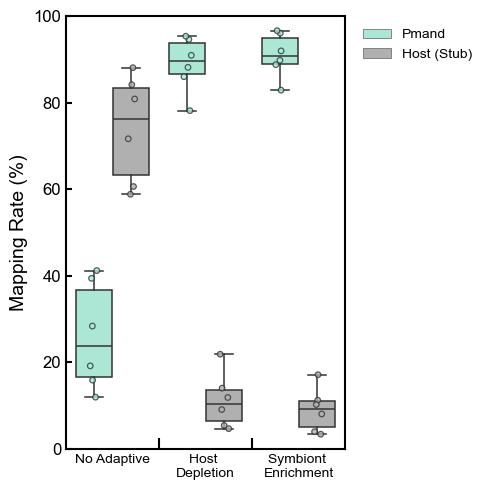

In [8]:
#plot mapping percent
long_frac = bases_df.melt(
    id_vars=["sample_group", "barcode_group"],
    value_vars=["Pmand_frac_of_mapped", "Stub_frac_of_mapped"],
    var_name="ref",
    value_name="fraction"
)

long_frac["ref"] = long_frac["ref"].map({
    "Pmand_frac_of_mapped": "Pmand",
    "Stub_frac_of_mapped": "Host (Stub)"
})

long_frac.to_csv( "XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1C_SourceData.csv", index=False)

plot_palette = {
    "Pmand": palette["Pmand"],
    "Host (Stub)": palette["Stub"]
}

fig, ax = plt.subplots(figsize=(5, 5))

sns.boxplot(
    data=long_frac,
    x="sample_group",
    y="fraction",
    hue="ref",
    palette=plot_palette,
    showfliers=False,
    linewidth=1.1,
    boxprops=dict(edgecolor='#333333'),
    whiskerprops=dict(color='#333333', linewidth=1.1),
    capprops=dict(color='#333333', linewidth=1.1),
    medianprops=dict(color='#333333', linewidth=1.1),
    ax=ax
)

sns.stripplot(
    data=long_frac,
    x="sample_group",
    y="fraction",
    hue="ref",
    palette=plot_palette,
    dodge=True,
    jitter=True,
    alpha=0.8,
    size=4,
    edgecolor='#333333',
    linewidth=0.9,
    ax=ax
)

#legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[:2], labels[:2],
    title="",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10
)

#axes
ax.set_ylim(0, 100)
ax.set_ylabel("Mapping Rate (%)", fontsize=14)
ax.set_xlabel("")

ax.tick_params(axis='y', direction='in', length=4, width=1.5, labelsize=12)
ax.tick_params(axis='x', which='major', length=0, labelsize=10)

#x-axis ticks between groups
groups = long_frac["sample_group"].dropna().unique()
n = len(groups)
boundaries = np.arange(0.5, n - 0.5, 1)

ax.set_xticks(boundaries, minor=True)
ax.tick_params(axis='x', which='minor', direction='in', length=8, width=1.5, pad=6)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1C.pdf', dpi=1200)
plt.show()

In [9]:
medians = (
    long_frac
    .groupby(["sample_group", "ref"])["fraction"]
    .median()
    .reset_index()
)

print(medians)

            sample_group          ref   fraction
0       Host \nDepletion  Host (Stub)  10.471808
1       Host \nDepletion        Pmand  89.528192
2            No Adaptive  Host (Stub)  76.230840
3            No Adaptive        Pmand  23.769160
4  Symbiont \nEnrichment  Host (Stub)   9.149951
5  Symbiont \nEnrichment        Pmand  90.850049


In [10]:
bases_df["Pmand_Stub_ratio_bases"] = (
    bases_df["Pmand_mapped_bases"] /
    bases_df["Stub_mapped_bases"].replace(0, np.nan)
)

long_bases = bases_df[[
    "sample_group",
    "barcode_group",
    "Pmand_Stub_ratio_bases"
]].copy()

long_bases.to_csv( "XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1D_SourceData.csv", index=False)

In [11]:
median_table = (
    long_bases
    .groupby("sample_group")["Pmand_Stub_ratio_bases"]
    .median()
    .reset_index()
    .rename(columns={"Pmand_Stub_ratio_bases": "Median"})
)
median_table["Median"] = median_table["Median"].apply(lambda x: f"{x:.3g}")

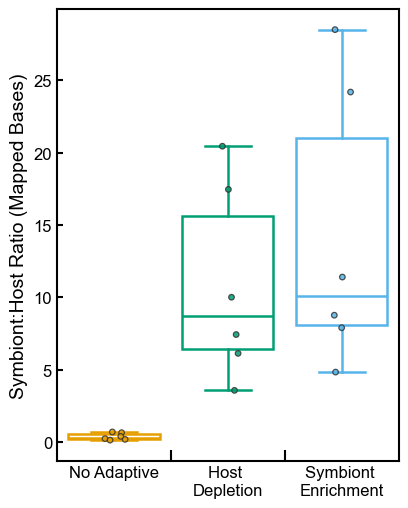

In [12]:
#Ratio Pmand:Stub by condition
fig, ax = plt.subplots(figsize=(4, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

condition_color_map = {
    "No Adaptive": "#E69F00",
    "Host \nDepletion": "#009E73",
    "Symbiont \nEnrichment": "#56B4E9",
}

order = list(condition_color_map.keys())

sns.boxplot(
    data=long_bases,
    x="sample_group",
    y="Pmand_Stub_ratio_bases",
    order=order,
    showfliers=False,
    color="white",
    linewidth=1.8,
    ax=ax
)

#apply colormapping to boxes
for patch, label in zip(ax.patches, order):
    color = condition_color_map[label]
    patch.set_facecolor("none")
    patch.set_edgecolor(color)
    patch.set_linewidth(1.8)

# apply colormapping to lines
lines_per_box = 5  # whiskers(2), caps(2), median(1)
for i, label in enumerate(order):
    color = condition_color_map[label]
    for line in ax.lines[i * lines_per_box:(i + 1) * lines_per_box]:
        line.set_color(color)
        line.set_linewidth(1.8)

# ---- stripplot (colored points) ----
sns.stripplot(
    data=long_bases,
    x="sample_group",
    y="Pmand_Stub_ratio_bases",
    order=order,
    jitter=True,
    size=4,
    linewidth=0.9,
    edgecolor="#333333",
    alpha=0.85,
    palette=condition_color_map,
    hue="sample_group",
    dodge=False,
    ax=ax
)

# remove legend from stripplot
if ax.get_legend():
    ax.get_legend().remove()

# ---- labels ----
ax.set_ylabel("Symbiont:Host Ratio (Mapped Bases)", fontsize=14)
ax.set_xlabel("")

# ---- ticks ----
ax.tick_params(axis='y', direction='in', length=4, width=1.5, labelsize=12)
ax.tick_params(axis='x', which='major', length=0, labelsize=12)

# ---- boundary ticks ----
n = len(order)
boundaries = np.arange(0.5, n - 0.5, 1)
ax.set_xticks(boundaries, minor=True)
ax.tick_params(axis='x', which='minor', direction='in', length=8, width=1.5, pad=6)

# ---- tighten x spacing ----
ax.set_xlim(-0.5, n - 0.5)

# ---- frame ----
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout(pad=0.4)
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1D.pdf', dpi=1200)
plt.show()

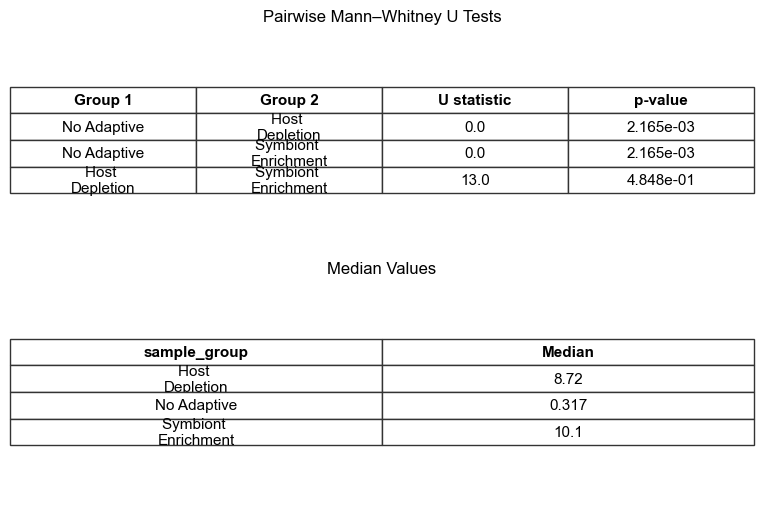

In [13]:
groups = long_bases["sample_group"].unique()

results = []

for g1, g2 in itertools.combinations(groups, 2):
    x = long_bases.loc[long_bases["sample_group"] == g1, "Pmand_Stub_ratio_bases"]
    y = long_bases.loc[long_bases["sample_group"] == g2, "Pmand_Stub_ratio_bases"]

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    results.append({
        "Group 1": g1,
        "Group 2": g2,
        "U statistic": stat,
        "p-value": p
    })

p_table = pd.DataFrame(results)
p_table

display_table = p_table.copy()
display_table["p-value"] = display_table["p-value"].apply(lambda x: f"{x:.3e}")


fig, axes = plt.subplots(2, 1, figsize=(8, 6))
fig.patch.set_facecolor("white")

# ---- P-value table ----
axes[0].axis("off")

table1 = axes[0].table(
    cellText=display_table.values,
    colLabels=display_table.columns,
    loc="center",
    cellLoc="center"
)

table1.auto_set_font_size(False)
table1.set_fontsize(11)
table1.scale(1.2, 1.6)

for (row, col), cell in table1.get_celld().items():
    cell.set_edgecolor("#333333")
    cell.set_linewidth(1.0)
    cell.set_facecolor("white")
    if row == 0:
        cell.set_text_props(weight="bold")

axes[0].set_title("Pairwise Mann–Whitney U Tests", fontsize=12, pad=10)

# ---- Median table ----
axes[1].axis("off")

table2 = axes[1].table(
    cellText=median_table.values,
    colLabels=median_table.columns,
    loc="center",
    cellLoc="center"
)

table2.auto_set_font_size(False)
table2.set_fontsize(11)
table2.scale(1.2, 1.6)

for (row, col), cell in table2.get_celld().items():
    cell.set_edgecolor("#333333")
    cell.set_linewidth(1.0)
    cell.set_facecolor("white")
    if row == 0:
        cell.set_text_props(weight="bold")

axes[1].set_title("Median Values", fontsize=12, pad=10)

plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Table1D.pdf', dpi=1200)

In [14]:
medians = (
    long_bases
    .groupby("sample_group")["Pmand_Stub_ratio_bases"]
    .median()
)
no_adaptive = medians["No Adaptive"]
pmand_enriched = medians["Symbiont \nEnrichment"]
stub_depleted = medians["Host \nDepletion"]
fc_pmand = pmand_enriched / no_adaptive
fc_stub = stub_depleted / no_adaptive

print("Fold change (Pmand_enriched / noAdaptive):", fc_pmand)
print("Fold change (Stub_depleted / noAdaptive):", fc_stub)

Fold change (Pmand_enriched / noAdaptive): 31.8564627385562
Fold change (Stub_depleted / noAdaptive): 27.544069051987766


In [15]:
#Different minimum length filtering thresholds comparison of ratio Pmand:Stub by condition 
barcodes = [f"barcode0{i}" for i in range(1, 7)]
minlens = [1, 250, 500, 750, 1000, 1250, 1500]

PMAND_SUFFIX = ".Pmanda.sorted.bam"
STUB_SUFFIX  = ".Stub.sorted.bam"

def finite_pos(a):
    a = np.asarray(a)
    return a[np.isfinite(a) & (a > 0)]

def collect_bams(bam_dirs, pattern):
    out = []
    for d in bam_dirs:
        out.extend(sorted(d.glob(pattern)))
    return out

def mapped_bases_from_bams(bam_paths):
    if not bam_paths:
        return 0
    lens = np.concatenate([read_lengths_from_bam(b) for b in bam_paths]) 
    lens = finite_pos(lens)
    return int(lens.sum())

def conditions_for_minlen(minlen):
    ml = f"MinLength{minlen}"
    return {
        "noAdaptive": [Path(f"XXXXX/AdaptiveSequencing/Align_IK82/NoAdaptive/{ml}/bam")],
        "Stub_depleted": [Path(f"XXXXX/AdaptiveSequencing/Align_IK82/Stub_depleted/{ml}/bam")],
        "Pmand_enriched": [
            Path(f"XXXXX/AdaptiveSequencing/Align_IK82/Pmand_enriched/Pool1/{ml}/bam"),
            Path(f"XXXXX/AdaptiveSequencing/Align_IK82/Pmand_enriched/no_sample/{ml}/bam"),
        ],
    }

rows = []
for minlen in minlens:
    conditions = conditions_for_minlen(minlen)

    for cond, bam_dirs in conditions.items():
        if not any(d.exists() for d in bam_dirs):
            print(f"WARNING: skipping {cond} MinLength{minlen} (dir missing)")
            continue

        for bc in barcodes:
            pmand_bams = collect_bams(bam_dirs, f"{bc}_*{PMAND_SUFFIX}")
            stub_bams  = collect_bams(bam_dirs, f"{bc}_*{STUB_SUFFIX}")

            pmand_bases = mapped_bases_from_bams(pmand_bams)
            stub_bases  = mapped_bases_from_bams(stub_bams)

            total = pmand_bases + stub_bases
            ratio = (pmand_bases / stub_bases) if stub_bases > 0 else np.nan

            rows.append({
                "minlen": minlen,
                "sample_group": cond,
                "barcode_group": bc,
                "Pmand_mapped_bases": pmand_bases,
                "Stub_mapped_bases": stub_bases,
                "total_mapped_bases": total,
                "Pmand_Stub_ratio_bases": ratio,
            })

bases_df = pd.DataFrame(rows)

# Keep only finite ratios for plotting
plot_df = bases_df[np.isfinite(bases_df["Pmand_Stub_ratio_bases"])].copy()
plot_df.to_csv( "XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1E_SourceData.csv", index=False)

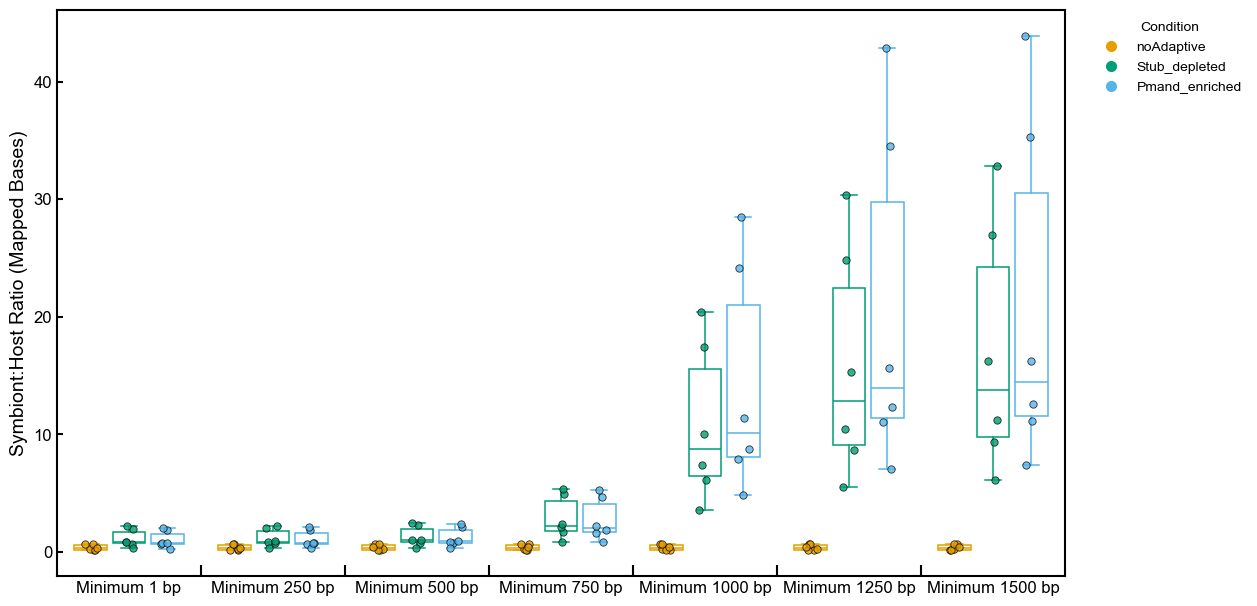

In [16]:
def cond_color(c):
    s = str(c).lower()
    if "no" in s and "adapt" in s:
        return "#E69F00"         
    if "enrich" in s:
        return "#56B4E9"        
    if "deplet" in s:
        return "#009E73"       
    return "#4d4d4d" 

def box_scatter_with_mean_lines(df, y="Pmand_Stub_ratio_bases"):
    minlens_sorted = sorted(df["minlen"].unique())
    conds = list(df["sample_group"].unique()) 

    colors = {c: cond_color(c) for c in conds}

    group_width = 0.8
    cond_width = group_width / max(len(conds), 1)
    offsets = {
        c: (-group_width / 2 + (i + 0.5) * cond_width)
        for i, c in enumerate(conds)
    }

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    rng = np.random.default_rng(42)

    for c in conds:
        col = colors[c]
        for i, ml in enumerate(minlens_sorted):
            sub = df[(df["sample_group"] == c) & (df["minlen"] == ml)][y].dropna().values
            if len(sub) == 0:
                continue

            x = i + offsets[c]

            ax.boxplot(
                [sub],
                positions=[x],
                widths=cond_width * 0.85,
                showfliers=False,
                patch_artist=True,
                boxprops=dict(facecolor="none", edgecolor=col, linewidth=1.1),
                medianprops=dict(color=col, linewidth=1.1),
                whiskerprops=dict(color=col, linewidth=1.1),
                capprops=dict(color=col, linewidth=1.1),
            )

            jitter = (rng.random(len(sub)) - 0.5) * (cond_width * 0.35)
            ax.scatter(
                np.full(len(sub), x) + jitter,
                sub,
                s=28,
                color=col,
                edgecolors='black',
                linewidths=0.6,
                alpha=0.8,
                zorder=10,
            )

    #ticks and labels
    ax.set_xticks(range(len(minlens_sorted)))
    ax.set_xticklabels([f"Minimum {m} bp" for m in minlens_sorted], rotation=0, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Symbiont:Host Ratio (Mapped Bases)", fontsize=14)
    ax.tick_params(axis='y', direction='in', length=4, width=1.5, labelsize=12)
    ax.tick_params(axis='x', which='major', length=0, labelsize=12)

    #x boundary ticks to separate groups
    n = len(minlens_sorted)
    boundaries = np.arange(0.5, n - 0.5, 1)
    ax.set_xticks(boundaries, minor=True)
    ax.tick_params(axis='x', which='minor', direction='in', length=8, width=1.5, pad=6)
    ax.set_xlim(-0.5, len(minlens_sorted) - 0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    #legend
    handles = [
        Line2D(
            [0], [0],
            marker='o',
            linestyle='none',
            markersize=7,
            markerfacecolor=colors[c],
            markeredgecolor=colors[c],
            label=str(c)
        )
        for c in conds
    ]

    ax.legend(
        handles=handles,
        frameon=False,
        title="Condition",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    return fig, ax

fig, ax = box_scatter_with_mean_lines(plot_df)
plt.tight_layout(pad=0.5)
plt.subplots_adjust(left=0.06, right=0.90)
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure1E.pdf', dpi=1200)
plt.show()

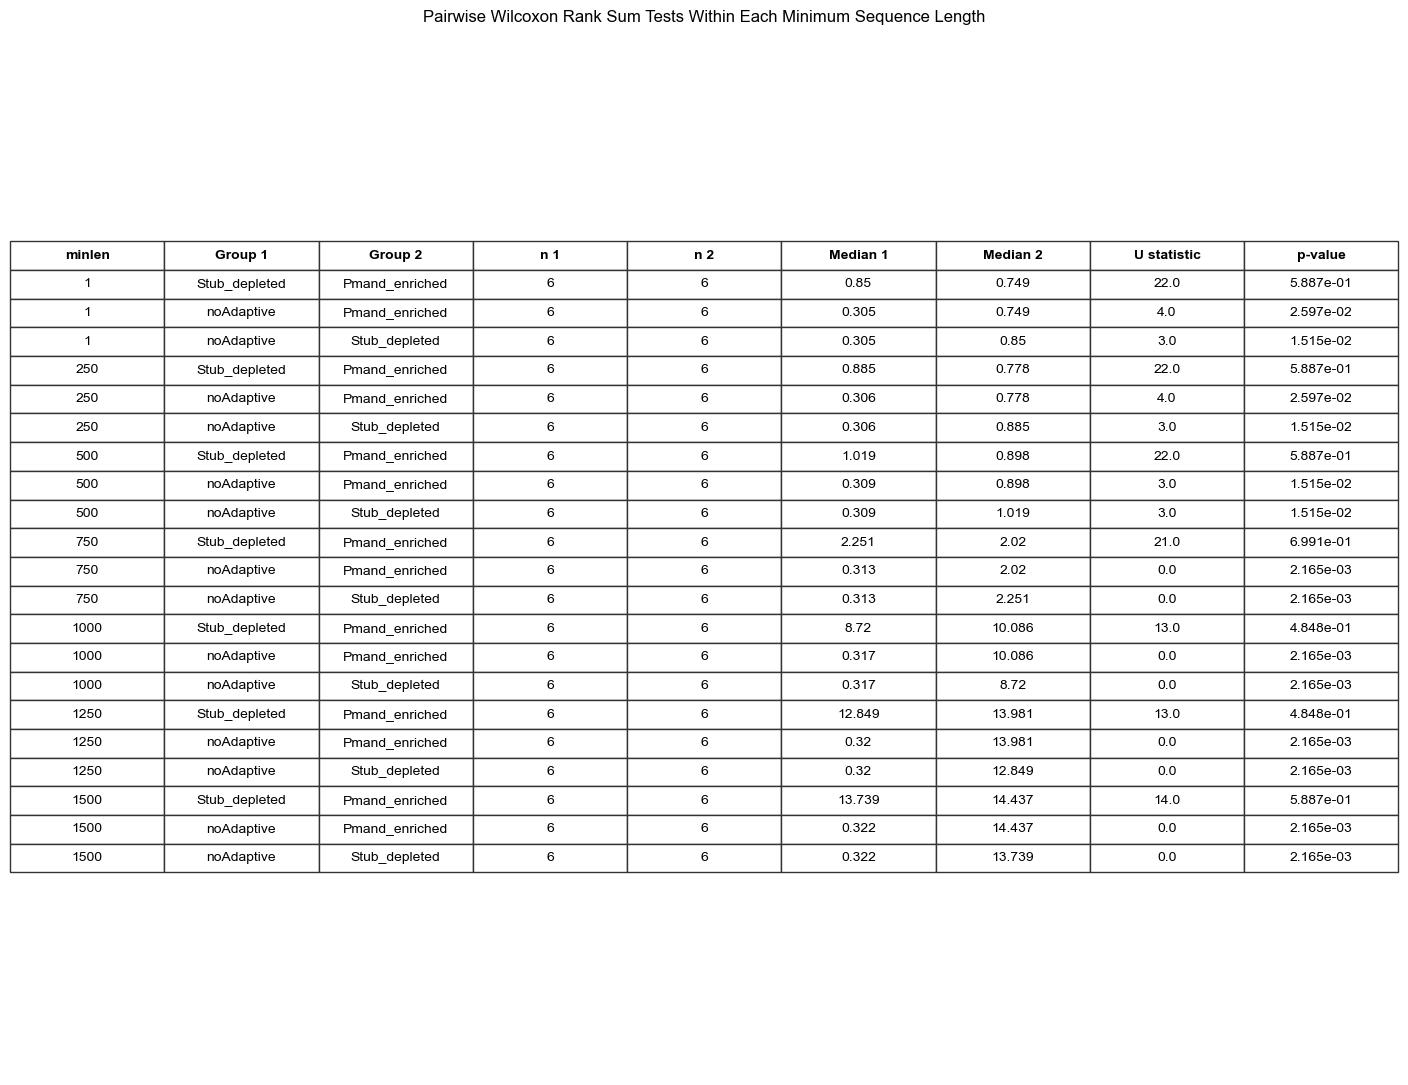

In [17]:
#Wilcoxon rank sum for conditions within min length filtering groups
results = []

minlens = sorted(bases_df["minlen"].dropna().unique())

for ml in minlens:
    df_ml = bases_df[bases_df["minlen"] == ml].copy()
    groups = df_ml["sample_group"].dropna().unique()

    for g1, g2 in itertools.combinations(groups, 2):
        x = df_ml.loc[df_ml["sample_group"] == g1, "Pmand_Stub_ratio_bases"].dropna()
        y = df_ml.loc[df_ml["sample_group"] == g2, "Pmand_Stub_ratio_bases"].dropna()

        if len(x) == 0 or len(y) == 0:
            continue

        stat, p = mannwhitneyu(x, y, alternative="two-sided")

        results.append({
            "minlen": ml,
            "Group 1": g1,
            "Group 2": g2,
            "n 1": len(x),
            "n 2": len(y),
            "Median 1": x.median(),
            "Median 2": y.median(),
            "U statistic": stat,
            "p-value": p
        })

p_table = pd.DataFrame(results)

#Make a table and save it as a PDF
display_table = p_table.copy()
display_table = display_table.sort_values(["minlen", "Group 1", "Group 2"]).reset_index(drop=True)

display_table["Median 1"] = display_table["Median 1"].round(3)
display_table["Median 2"] = display_table["Median 2"].round(3)
display_table["U statistic"] = display_table["U statistic"].round(3)
display_table["p-value"] = display_table["p-value"].apply(lambda x: f"{x:.3e}")

#print(display_table)

fig, ax = plt.subplots(figsize=(14, max(4, 0.45 * len(display_table) + 1.5)))
fig.patch.set_facecolor("white")
ax.axis("off")

table = ax.table(
    cellText=display_table.values,
    colLabels=display_table.columns,
    loc="center",
    cellLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.15, 1.4)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#333333")
    cell.set_linewidth(1.0)
    cell.set_facecolor("white")
    if row == 0:
        cell.set_text_props(weight="bold")

ax.set_title("Pairwise Wilcoxon Rank Sum Tests Within Each Minimum Sequence Length", fontsize=12, pad=12)

plt.tight_layout()
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Table1E.pdf', dpi=1200, bbox_inches="tight")
plt.show()

# Figure 2

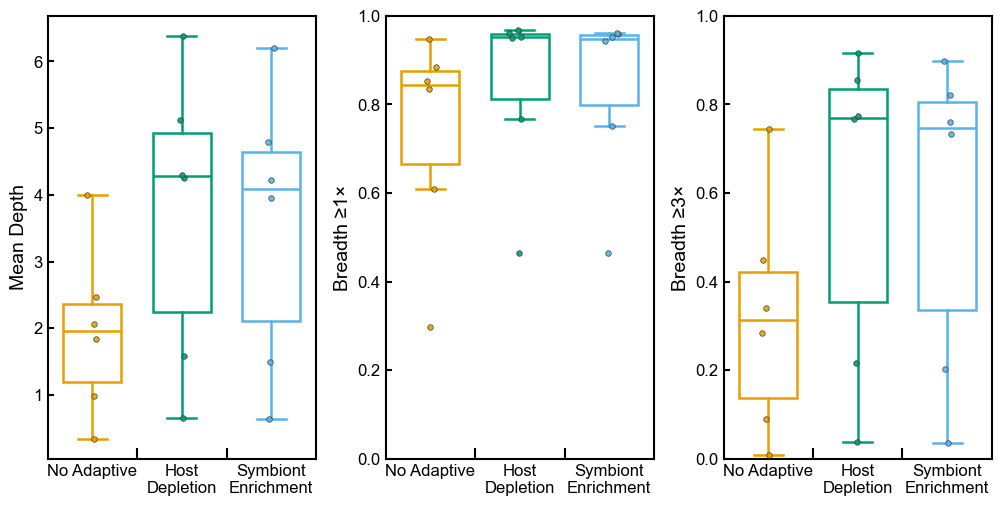

In [18]:
#Breadth and depth of coverage
df = pd.read_csv( "XXXXX/AdaptiveSequencing/DownsampledBases/Align_IK82/coverage_stats.tsv",sep="\t")

condition_order_raw = [
    "NoAdaptive",
    "Stub-depleted",
    "Pmand-enriched",
]

condition_label_map = {
    "NoAdaptive": "No Adaptive",
    "Stub-depleted": "Host\nDepletion",
    "Pmand-enriched": "Symbiont\nEnrichment",
}

condition_color_map = {
    "NoAdaptive": "#E69F00",
    "Stub-depleted": "#009E73",
    "Pmand-enriched": "#56B4E9",
}

metric_cols = [
    "mean_depth",
    "breadth_ge_1x",
    "breadth_ge_3x",
]

ylabels = [
    "Mean Depth",
    "Breadth ≥1×",
    "Breadth ≥3×",
]

plot_df = df[df["condition"].isin(condition_order_raw)].copy()
plot_df["condition_display"] = plot_df["condition"].map(condition_label_map)

plot_df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure2A-C_SourceData.csv",index=False)

#formatting
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

#plot
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(10, 5)
)
fig.patch.set_facecolor("white")
rng = np.random.default_rng(1)
positions = np.arange(1, len(condition_order_raw) + 1)
for ax, metric, ylabel in zip(axes, metric_cols, ylabels):
    data = [
        plot_df.loc[
            plot_df["condition"] == cond,
            metric
        ].dropna().values
        for cond in condition_order_raw
    ]

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.65,
        patch_artist=True,
        showfliers=False
    )
    for i, cond in enumerate(condition_order_raw):
        color = condition_color_map[cond]
        #boxplot
        bp["boxes"][i].set_facecolor("none")
        bp["boxes"][i].set_edgecolor(color)
        bp["boxes"][i].set_linewidth(1.8)

        bp["medians"][i].set_color(color)
        bp["medians"][i].set_linewidth(1.8)

        for whisker in bp["whiskers"][2*i:2*i+2]:
            whisker.set_color(color)
            whisker.set_linewidth(1.8)

        for cap in bp["caps"][2*i:2*i+2]:
            cap.set_color(color)
            cap.set_linewidth(1.8)
        
        #jitterplot 
        y = data[i]
        x = rng.normal(
            positions[i],
            0.045,
            size=len(y)
        )
        ax.scatter(
            x,
            y,
            s=16,
            color=color,
            edgecolor="#333333",
            linewidth=0.5,
            alpha=0.9,
            zorder=3
        )

    #axis formatting
    ax.set_xticks(positions)
    ax.set_xticklabels([condition_label_map[c]for c in condition_order_raw])
    ax.set_xlabel("")
    ax.set_ylabel(ylabel, fontsize=14)
    if metric in ["breadth_ge_1x", "breadth_ge_3x"]:
        ax.set_ylim(0, 1)
    n = len(condition_order_raw)
    boundaries = np.arange(1.5, n, 1)
    ax.set_xticks(boundaries, minor=True)
    ax.tick_params(
        axis='x',
        which='minor',
        direction='in',
        length=8,
        width=1.5,
        pad=6
    )
    ax.tick_params(
        axis='x',
        which='major',
        length=0,
        labelsize=12
    )
    ax.tick_params(
        axis='y',
        direction='in',
        length=4,
        width=1.5,
        labelsize=12
    )


    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout(pad=0.5, w_pad=1.0)
plt.savefig("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure2A-C.pdf",dpi=1200,bbox_inches="tight")
plt.show()

In [19]:
def pairwise_wilcoxon(df, value_col, group_col="condition"):
    groups = df[group_col].unique()
    results = []

    for i in range(len(groups)):
        for j in range(i + 1, len(groups)):
            g1 = groups[i]
            g2 = groups[j]

            x = df[df[group_col] == g1][value_col].dropna()
            y = df[df[group_col] == g2][value_col].dropna()

            stat, p = mannwhitneyu(x, y, alternative="two-sided")

            results.append({
                "Group 1": g1,
                "Group 2": g2,
                "Metric": value_col,
                "U statistic": stat,
                "p-value": p,
                "Median (G1)": x.median(),
                "Median (G2)": y.median()
            })

    res_df = pd.DataFrame(results)

    return res_df

In [20]:
metrics = ["mean_depth", "breadth_ge_1x", "breadth_ge_3x"]
wilcoxon_tables = []
for m in metrics:
    tbl = pairwise_wilcoxon(df, m)
    wilcoxon_tables.append(tbl)
wilcoxon_results = pd.concat(wilcoxon_tables, ignore_index=True)

wilcoxon_results

,Group 1,Group 2,Metric,U statistic,p-value,Median (G1),Median (G2)
0,NoAdaptive,Pmand-enriched,mean_depth,10.0,0.240260,1.953245,4.089486
1,NoAdaptive,Stub-depleted,mean_depth,9.0,0.179654,1.953245,4.276557
2,Pmand-enriched,Stub-depleted,mean_depth,14.0,0.588745,4.089486,4.276557
3,NoAdaptive,Pmand-enriched,breadth_ge_1x,10.0,0.240260,0.843972,0.947174
4,NoAdaptive,Stub-depleted,breadth_ge_1x,9.0,0.179654,0.843972,0.951234
5,Pmand-enriched,Stub-depleted,breadth_ge_1x,16.0,0.818182,0.947174,0.951234
6,NoAdaptive,Pmand-enriched,breadth_ge_3x,10.0,0.240260,0.312182,0.747683
7,NoAdaptive,Stub-depleted,breadth_ge_3x,9.0,0.179654,0.312182,0.770388
8,Pmand-enriched,Stub-depleted,breadth_ge_3x,14.0,0.588745,0.747683,0.770388


In [21]:
def compute_log2_fc(df, value_col, baseline="NoAdaptive"):
    medians = df.groupby("condition")[value_col].median()
    baseline_val = medians[baseline]
    results = []
    for cond in medians.index:
        if cond == baseline:
            continue
        fc = medians[cond] / baseline_val
        log2_fc = np.log2(fc)
        results.append({
            "Metric": value_col,
            "Condition": cond,
            "Median": medians[cond],
            "Baseline median": baseline_val,
            "Fold change": fc,
            "log2 Fold change": log2_fc
        })

    return pd.DataFrame(results)
    
fc_tables = []
for m in metrics:
    fc_tables.append(compute_log2_fc(df, m))
fc_results = pd.concat(fc_tables, ignore_index=True)

fc_results

,Metric,Condition,Median,Baseline median,Fold change,log2 Fold change
0,mean_depth,Pmand-enriched,4.089486,1.953245,2.093688,1.066046
1,mean_depth,Stub-depleted,4.276557,1.953245,2.189462,1.130576
2,breadth_ge_1x,Pmand-enriched,0.947174,0.843972,1.122281,0.166434
3,breadth_ge_1x,Stub-depleted,0.951234,0.843972,1.127091,0.172604
4,breadth_ge_3x,Pmand-enriched,0.747683,0.312182,2.395017,1.260036
5,breadth_ge_3x,Stub-depleted,0.770388,0.312182,2.467749,1.303196


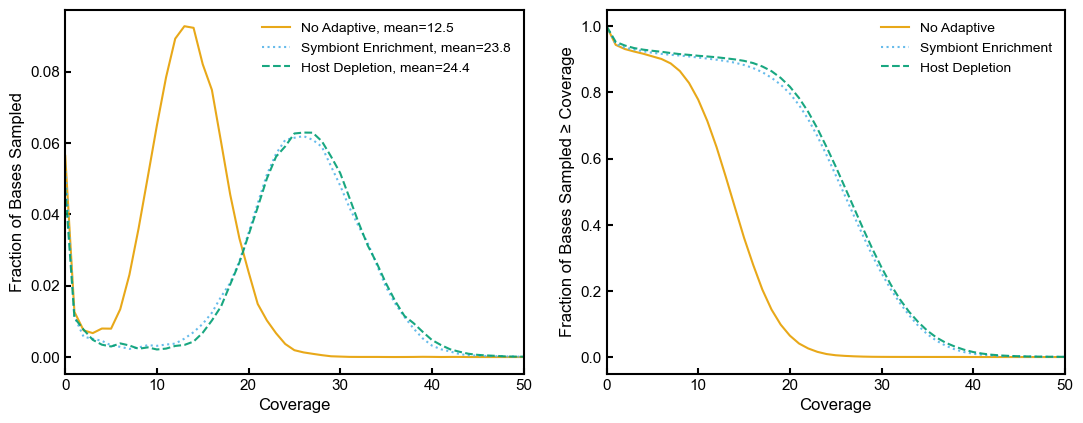

In [22]:
#Coverage vs fraction of bases sampled; Coverage uniformity, pooled across genome
tsv_path = "XXXXX/AdaptiveSequencing/DownsampledBases/plotCoverage_pooled/Pmand.plotCoverage.POOLED.Pmanda.PREDOWNSAMPLED.raw.tsv"

raw = pd.read_csv(tsv_path, sep="\t", header=None, comment="#", engine="python")
raw = raw.rename(columns={
    0: "chrom",
    1: "start",
    2: "end",
    3: "noAdaptive",
    4: "enrich",
    5: "deplete",
})

# Keep only the full chromosomes, not the plasmid(s)
keep_chroms = ["NZ_CP183280.1", "NZ_CP183282.1"]
raw = raw[raw["chrom"].isin(keep_chroms)].copy()

conditions = ["noAdaptive", "enrich", "deplete"]

condition_color_map = {
    "noAdaptive": "#E69F00",
    "deplete": "#009E73",
    "enrich": "#56B4E9",
}

condition_linestyle_map = {
    "noAdaptive": "-",
    "deplete": "--",
    "enrich": ":",
}

label_map = {
    "noAdaptive": "No Adaptive",
    "enrich": "Symbiont Enrichment",
    "deplete": "Host Depletion",
}

# deepTools sampled positions, each with a coverage value per sample
max_cov = int(np.nanmax(raw[conditions].values))
coverage_values = np.arange(0, max_cov + 1)

hist_df = pd.DataFrame({"coverage": coverage_values})
cdf_ge_df = pd.DataFrame({"coverage": coverage_values})
means = {}

for cond in conditions:
    vals = raw[cond].dropna().astype(float).values
    vals = np.rint(vals).astype(int)
    counts = np.bincount(vals, minlength=max_cov + 1)
    frac = counts / counts.sum()
    hist_df[cond] = frac
    cdf_ge_df[cond] = frac[::-1].cumsum()[::-1]
    means[cond] = np.sum(coverage_values * frac)

hist_df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure2D_SourceData.csv",index=False)
cdf_ge_df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure2E_SourceData.csv",index=False)

#plot
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), sharex=True)
fig.patch.set_facecolor("white")

#Coverage vs. Fraction of basses sampled 
ax = axes[0]
ax.set_facecolor("white")

for cond in conditions:
    ax.plot(
        hist_df["coverage"],
        hist_df[cond],
        color=condition_color_map[cond],
        linestyle=condition_linestyle_map[cond],
        linewidth=1.5,
        alpha=0.9,
        label=f"{label_map[cond]}, mean={means[cond]:.1f}"
    )

ax.set_xlabel("Coverage", fontsize=12)
ax.set_ylabel("Fraction of Bases Sampled", fontsize=12)

ax.tick_params(axis='x', direction='in', length=4, width=1.5, labelsize=11)
ax.tick_params(axis='y', direction='in', length=4, width=1.5, labelsize=11)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.legend(frameon=False, fontsize=10, loc="upper right")

#Coverage vs. fraction of sampled bases with coverage where fraction of basses sampled exceeds coverage
ax = axes[1]
ax.set_facecolor("white")

for cond in conditions:
    ax.plot(
        cdf_ge_df["coverage"],
        cdf_ge_df[cond],
        color=condition_color_map[cond],
        linestyle=condition_linestyle_map[cond],
        linewidth=1.5,
        alpha=0.9,
        label=label_map[cond]
    )

ax.set_xlabel("Coverage", fontsize=12)
ax.set_ylabel("Fraction of Bases Sampled ≥ Coverage", fontsize=12)
ax.tick_params(axis='x', direction='in', length=4, width=1.5, labelsize=11)
ax.tick_params(axis='y', direction='in', length=4, width=1.5, labelsize=11)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.legend(frameon=False, fontsize=10, loc="upper right")

xmax = hist_df["coverage"].max()
axes[0].set_xlim(0, 50)
axes[1].set_xlim(0, 50)

plt.tight_layout(pad=0.6, w_pad=2.0)
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure2D-E.pdf', dpi=1200)
plt.show()

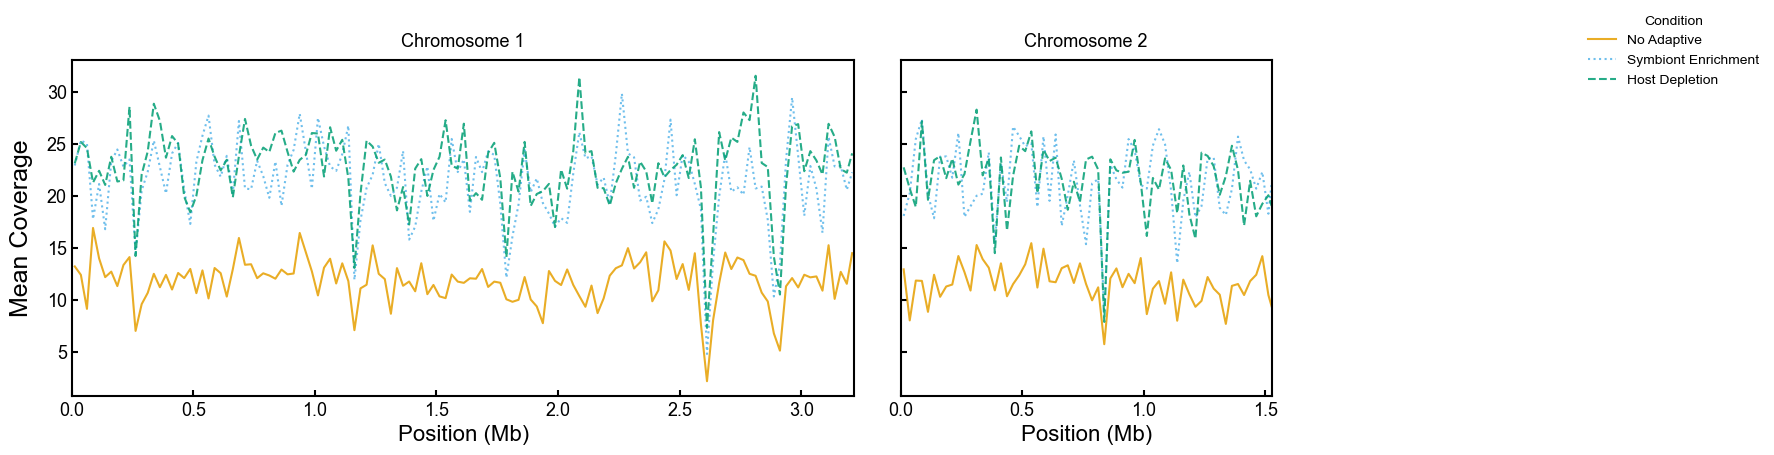

In [23]:
#Coverage uniformity, genome wide by positioonal bin
files = {
    "noAdaptive": "XXXXX/AdaptiveSequencing/DownsampledBases/Align_IK82/mosdepth_25kb_IK82/noAdaptive.25kb.regions.bed.gz",
    "enrich": "XXXXX/AdaptiveSequencing/DownsampledBases/Align_IK82/mosdepth_25kb_IK82/enrich.25kb.regions.bed.gz",
    "deplete": "XXXXX/AdaptiveSequencing/DownsampledBases/Align_IK82/mosdepth_25kb_IK82/deplete.25kb.regions.bed.gz",
}

condition_color_map = {
    "noAdaptive": "#E69F00",
    "deplete": "#009E73",
    "enrich": "#56B4E9",
}

condition_linestyle_map = {
    "noAdaptive": "-",
    "deplete": "--",
    "enrich": ":",
}

label_map = {
    "noAdaptive": "No Adaptive",
    "deplete": "Host Depletion",
    "enrich": "Symbiont Enrichment",
}

chrom_label_map = {
    "NZ_CP131594.1": "Chromosome 1",
    "NZ_CP131593.1": "Chromosome 2",
}

keep_chroms = list(chrom_label_map.keys())

def read_regions(path):
    rows = []
    with gzip.open(path, "rt") as f:
        for line in f:
            chrom, start, end, cov = line.rstrip("\n").split("\t")
            rows.append((chrom, int(start), int(end), float(cov)))
    df = pd.DataFrame(rows, columns=["chrom", "start", "end", "cov"])
    df["mid"] = (df["start"] + df["end"]) / 2.0
    return df

dfs = {k: read_regions(v) for k, v in files.items()}

dfs = {
    k: df[df["chrom"].isin(keep_chroms)].copy()
    for k, df in dfs.items()
}

chrom_order = list(dfs["noAdaptive"]["chrom"].drop_duplicates())

chrom_lengths = (
    dfs["noAdaptive"]
    .groupby("chrom")["end"]
    .max()
    .to_dict()
)

tick_interval = 500_000  # 0.5 Mb
width_ratios = [chrom_lengths[c] for c in chrom_order]

#plot
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 4.8),
    sharey=True,
    gridspec_kw={"width_ratios": width_ratios, "wspace": 0.08}
)
fig.patch.set_facecolor("white")

if len(chrom_order) == 1:
    axes = [axes]

for ax, chrom in zip(axes, chrom_order):
    ax.set_facecolor("white")

    chrom_len = chrom_lengths[chrom]

    for label, df in dfs.items():
        sub = df[df["chrom"] == chrom].copy().sort_values("mid")
        if sub.empty:
            continue

        ax.plot(
            sub["mid"],
            sub["cov"],
            color=condition_color_map[label],
            linestyle=condition_linestyle_map[label],
            linewidth=1.5,
            alpha=0.85,
            label=label_map[label]
        )

    ax.set_xlim(0, chrom_len)
    ticks = np.arange(0, chrom_len + 1, tick_interval)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{t/1e6:.1f}" for t in ticks])
    ax.set_title(chrom_label_map[chrom], fontsize=13, pad=10)
    ax.set_xlabel("Position (Mb)", fontsize=16)
    ax.tick_params(axis='y', direction='in', length=4, width=1.5, labelsize=13)
    ax.tick_params(axis='x', direction='in', length=4, width=1.5, labelsize=13)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

axes[0].set_ylabel("Mean Coverage", fontsize=18, labelpad=10)
if len(axes) > 1:
    axes[1].set_ylabel("")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    title="Condition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.subplots_adjust(left=0.08, right=0.83, bottom=0.18, top=0.88)
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure2F.pdf', dpi=1200)
plt.show()

In [24]:
source_tables = []

for condition, df_cond in dfs.items():
    tmp = df_cond[["chrom", "start", "end", "mid", "cov"]].copy()
    tmp = tmp.rename(columns={"cov": label_map[condition]})
    source_tables.append(tmp)

coverage_source_df = source_tables[0]

for tmp in source_tables[1:]:
    coverage_source_df = coverage_source_df.merge(
        tmp,
        on=["chrom", "start", "end", "mid"],
        how="outer"
    )

coverage_source_df["chromosome_label"] = coverage_source_df["chrom"].map(chrom_label_map)

coverage_source_df = coverage_source_df[
    [
        "chrom",
        "chromosome_label",
        "start",
        "end",
        "mid",
        "No Adaptive",
        "Symbiont Enrichment",
        "Host Depletion",
    ]
]

coverage_source_df = coverage_source_df.sort_values(
    ["chrom", "start", "end"]
)

coverage_source_df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure2F_SourceData.csv",index=False)

# Figure 3

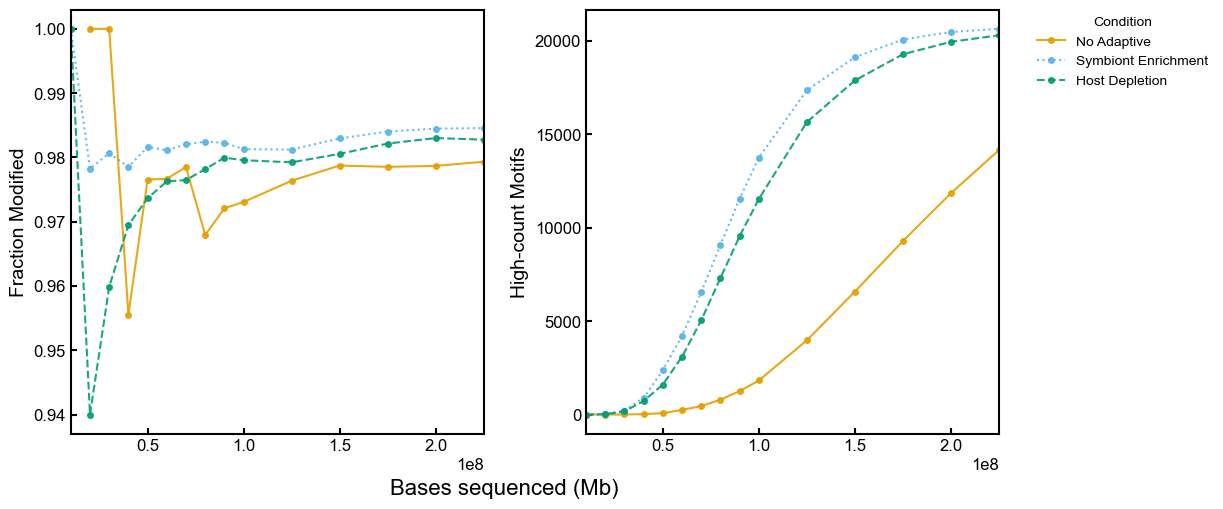

In [25]:
#Fraction modified (6mA methylated = modified), High count motifs identified genome wide
plot_df = pd.read_csv("XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/Figure4_rawStatistics.tsv", sep="\t")
plot_df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure3A-B_SourceData.csv",index=False)

EXPECTED_TYPES = ["NoAdaptive", "Pmand_enriched", "Stub_depleted"]

label_map = {
    "NoAdaptive": "No Adaptive",
    "Pmand_enriched": "Symbiont Enrichment",
    "Stub_depleted": "Host Depletion",
}

condition_color_map = {
    "NoAdaptive": "#E69F00",
    "Pmand_enriched": "#56B4E9",
    "Stub_depleted": "#009E73",
}

condition_linestyle_map = {
    "NoAdaptive": "-",
    "Pmand_enriched": ":",
    "Stub_depleted": "--",
}

metrics = [
    ("frac_mod", "Fraction Modified", False),
    ("high_count", "High-count Motifs", False),
]

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
fig.patch.set_facecolor("white")

for ax, (metric, ylabel, drop_inf) in zip(axes, metrics):
    df = plot_df.copy()
    for type_name in EXPECTED_TYPES:
        sub = df[df["Type"] == type_name].copy()
        if sub.empty:
            continue

        sub = sub.sort_values("actual_total_bases")

        ax.plot(
            sub["actual_total_bases"],
            sub[metric],
            color=condition_color_map[type_name],
            linestyle=condition_linestyle_map[type_name],
            linewidth=1.5,
            marker="o",
            markersize=4,
            alpha=0.9,
            label=label_map[type_name]
        )

    ax.set_facecolor("white")
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='x', direction='in', length=4, width=1.5, labelsize=12)
    ax.tick_params(axis='y', direction='in', length=4, width=1.5, labelsize=12)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)


fig.supxlabel("Bases sequenced (Mb)", fontsize=16)
sci_formatter = ScalarFormatter(useMathText=False)  # <- key change
sci_formatter.set_scientific(True)
sci_formatter.set_powerlimits((0, 0))

xmin = plot_df["actual_total_bases"].min()
xmax = plot_df["actual_total_bases"].max()
for ax in axes:
    ax.set_xlim(xmin, xmax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    frameon=False,
    title="Condition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout(pad=0.4, w_pad=2.0)
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure3A-B.pdf', dpi=1200)
plt.show()

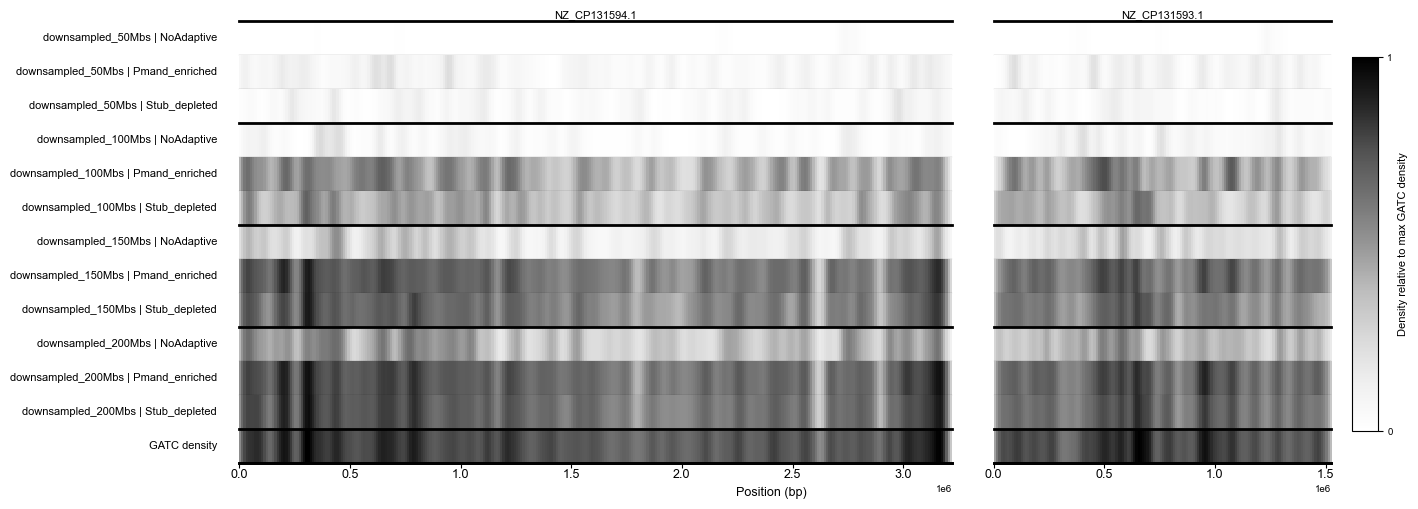

In [26]:
#Methylation genome wide by bins compared with GATC density 

%run XXXXX/AdaptiveSequencing/MethylationCalls/merged_modbams/plot_bedMethyl_HeatmapTrack_withGATC.py \
    XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/downsampled_50Mbs \
    XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/downsampled_100Mbs \
    XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/downsampled_150Mbs \
    XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/downsampled_200Mbs \
    -o XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure3C.pdf \
    --chroms NZ_CP131594.1 NZ_CP131593.1


In [27]:
#Binary co-occurence matrix for low methlation & low coevrage 
def count_gatc_per_bin(fasta_path, bin_size=10000):
    counts = defaultdict(int)

    with open(fasta_path) as f:
        chrom = None
        seq_chunks = []

        for line in f:
            line = line.strip()
            if line.startswith(">"):
                # process previous chromosome
                if chrom is not None:
                    seq = "".join(seq_chunks).upper()
                    for i in range(len(seq) - 3):
                        if seq[i:i+4] == "GATC":
                            bin_start = (i // bin_size) * bin_size
                            counts[(chrom, bin_start)] += 1

                chrom = line[1:].split()[0]
                seq_chunks = []
            else:
                seq_chunks.append(line)

        # last chromosome
        if chrom is not None:
            seq = "".join(seq_chunks).upper()
            for i in range(len(seq) - 3):
                if seq[i:i+4] == "GATC":
                    bin_start = (i // bin_size) * bin_size
                    counts[(chrom, bin_start)] += 1

    return counts

def motif_counts_to_df(counts, bin_size=10000):
    rows = []
    for (chrom, bin_start), n in counts.items():
        rows.append({
            "chrom": chrom,
            "bin_start": bin_start,
            "bin_end": bin_start + bin_size,
            "gatc_motif_count": n
        })

    return pd.DataFrame(rows)

fasta_path = "XXXXX/AdaptiveSequencing/GCF_030685395.1_ASM3068539v1_genomic.fna"

motif_counts = count_gatc_per_bin(fasta_path, bin_size=10000)
motif_df = motif_counts_to_df(motif_counts)

Coverage thresholds by chromosome:
chrom
NZ_CP131593.1    8.676
NZ_CP131594.1    8.400
Name: coverage_threshold, dtype: float64

Recovery thresholds by chromosome:
chrom
NZ_CP131593.1    0.960630
NZ_CP131594.1    0.971905
Name: recovery_threshold, dtype: float64

Fraction of bins flagged as low coverage + low recovery:
chrom          condition          
NZ_CP131593.1  Host Depletion         0.013245
               No Adaptive            0.324503
               Symbiont Enrichment    0.013245
NZ_CP131594.1  Host Depletion         0.028125
               No Adaptive            0.322884
               Symbiont Enrichment    0.025000
Name: co_occurrence, dtype: float64

Chromosome lengths inferred from binned tables:
{'NZ_CP131594.1': 3210000.0, 'NZ_CP131593.1': 1520000.0}


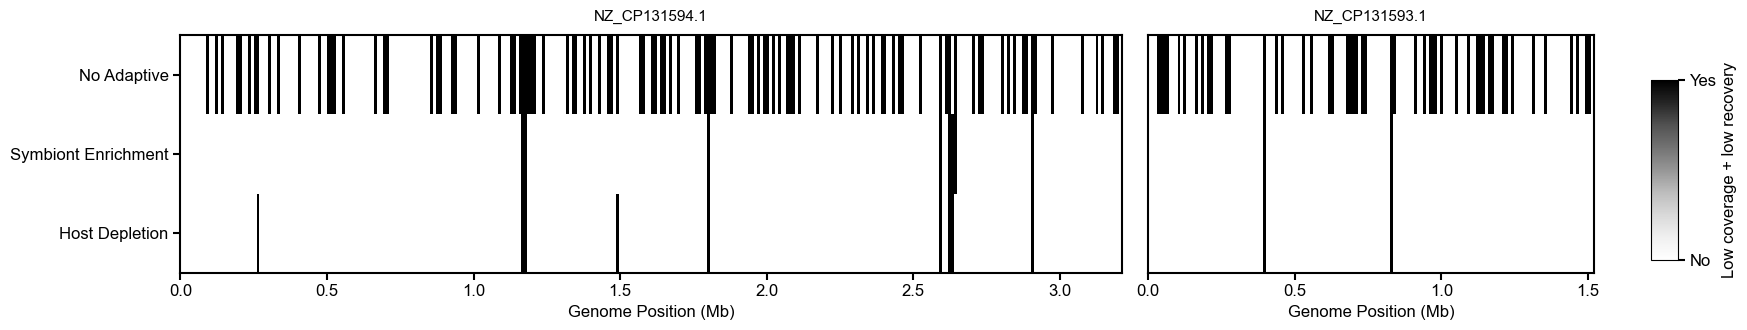

In [28]:
depth_folders = {
    "50 Mb": "XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/downsampled_50Mbs",
    "100 Mb": "XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/downsampled_100Mbs",
    "150 Mb": "XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/downsampled_150Mbs",
    "200 Mb": "XXXXX/AdaptiveSequencing/MethylationCalls/OtherRefGenome/downsampled_200Mbs",
}

file_mask = "*BinnedMethylation_Coverage.tsv"

chromosomes = ["NZ_CP131594.1", "NZ_CP131593.1"]
final_depth = "200 Mb"

condition_name_map = {
    "NoAdaptive": "No Adaptive",
    "Pmand_enriched": "Symbiont Enrichment",
    "Stub_depleted": "Host Depletion",
}

condition_order = ["No Adaptive", "Symbiont Enrichment", "Host Depletion"]

# choose threshold for "low" coverage and "low" recovery; thresholds will be specific to each chromosome (so lowest 20% on chromosome 1 and lowest 20% on chromosome 2)
coverage_quantile_threshold = 0.20
recovery_quantile_threshold = 0.20


def infer_condition_label(filepath, name_map=None):
    stem = Path(filepath).stem
    if name_map is not None:
        for raw, pretty in name_map.items():
            if raw in stem:
                return pretty
    return stem

def load_binned_tables(depth_folders, file_mask="*BinnedMethylation_Coverage.tsv", name_map=None):
    dfs = []

    for depth_label, folder in depth_folders.items():
        folder = Path(folder)
        files = sorted(folder.glob(file_mask))

        if not files:
            print(f"Warning: no files matched {file_mask} in {folder}")
            continue

        for fp in files:
            df = pd.read_csv(fp, sep="\t")
            df["depth_label"] = depth_label
            df["condition"] = infer_condition_label(fp.name, name_map=name_map)
            df["source_file"] = fp.name
            dfs.append(df)

    if not dfs:
        raise ValueError("No files were loaded. Check your folder paths and file mask.")

    combined = pd.concat(dfs, ignore_index=True)

    for col in [
        "bin_start", "bin_end", "n_sites", "sum_site_coverage",
        "mean_site_coverage", "modified_sum", "canonical_sum",
        "callable_read_sum", "binned_methylation_fraction", "mean_coverage"
    ]:
        if col in combined.columns:
            combined[col] = pd.to_numeric(combined[col], errors="coerce")

    return combined

df_all = load_binned_tables(
    depth_folders=depth_folders,
    file_mask=file_mask,
    name_map=condition_name_map,
)

df_all = df_all.merge(
    motif_df,
    on=["chrom", "bin_start", "bin_end"],
    how="left"
)

df_all["total_sites"] = df_all["gatc_motif_count"] * 2
df_all["recovery"] = df_all["n_sites"] / df_all["total_sites"]
df_plot = df_all.dropna(subset=["chrom", "bin_start", "bin_end", "mean_coverage", "recovery", "depth_label", "condition"]).copy()

df_plot = df_plot[
    np.isfinite(df_plot["mean_coverage"]) &
    np.isfinite(df_plot["recovery"]) &
    (df_plot["mean_coverage"] >= 0) &
    (df_plot["recovery"] >= 0)
].copy()

# keep only final depth and requested chromosomes
df_plot = df_plot[
    (df_plot["depth_label"] == final_depth) &
    (df_plot["chrom"].isin(chromosomes))
].copy()


df_plot["coverage_threshold"] = (
    df_plot.groupby("chrom")["mean_coverage"]
    .transform(lambda x: x.quantile(coverage_quantile_threshold))
)

df_plot["recovery_threshold"] = (
    df_plot.groupby("chrom")["recovery"]
    .transform(lambda x: x.quantile(recovery_quantile_threshold))
)

df_plot["low_cov"] = df_plot["mean_coverage"] <= df_plot["coverage_threshold"]
df_plot["low_rec"] = df_plot["recovery"] <= df_plot["recovery_threshold"]
df_plot["co_occurrence"] = (df_plot["low_cov"] & df_plot["low_rec"]).astype(int)
df_plot["norm_coverage"] = (df_plot.groupby("chrom")["mean_coverage"].transform(lambda x: x / x.max()))
df_plot["coverage_weighted_recovery"] = df_plot["recovery"] * df_plot["norm_coverage"]

print("Coverage thresholds by chromosome:")
print(df_plot.groupby("chrom")["coverage_threshold"].first())

print("\nRecovery thresholds by chromosome:")
print(df_plot.groupby("chrom")["recovery_threshold"].first())

print("\nFraction of bins flagged as low coverage + low recovery:")
print(df_plot.groupby(["chrom", "condition"])["co_occurrence"].mean())

heatmap_df = (
    df_plot.groupby(["chrom", "condition", "bin_start", "bin_end"], as_index=False)
    .agg(co_occurrence=("co_occurrence", "max"))
    .sort_values(["chrom", "condition", "bin_start"])
    .copy()
)

source_df = (heatmap_df[["chrom","condition","bin_start", "bin_end", "co_occurrence"]].copy())
source_df["condition"] = pd.Categorical(source_df["condition"], categories=condition_order,ordered=True)
source_df = source_df.sort_values( ["chrom", "condition", "bin_start"])
source_df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure3D_SourceData.csv",index=False)

heatmap_mats = {}
chrom_lengths = {}
for chrom in chromosomes:
    sub = heatmap_df[heatmap_df["chrom"] == chrom].copy()
    mat = (sub.pivot(index="condition", columns="bin_start", values="co_occurrence").reindex(condition_order))
    heatmap_mats[chrom] = mat
    chrom_lengths[chrom] = sub["bin_end"].max()

print("\nChromosome lengths inferred from binned tables:")
print(chrom_lengths)


#plot
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(chromosomes),
    figsize=(18, 3.4),
    gridspec_kw={"width_ratios": [chrom_lengths[c] for c in chromosomes]},
    squeeze=False
)

for j, chrom in enumerate(chromosomes):
    ax = axes[0, j]
    mat = heatmap_mats[chrom]

    x_max = chrom_lengths[chrom] / 1e6  # Mb

    im = ax.imshow(
        mat.values,
        aspect="auto",
        cmap="Greys",
        vmin=0,
        vmax=1,
        interpolation="nearest",
        extent=[0, x_max, len(condition_order), 0]
    )

    ax.set_title(chrom, pad=10)
    ax.set_yticks(np.arange(len(condition_order)) + 0.5)
    if j == 0:
        ax.set_yticklabels(condition_order)
    else:
        ax.set_yticklabels([])
        ax.tick_params(axis="y", left=False)
    xticks = np.arange(0, x_max + 0.001, 0.5)
    ax.set_xticks(xticks)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Genome Position (Mb)")
    ax.tick_params(direction="out", width=1.5, length=5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

#legend  colorbar
cax = fig.add_axes([0.92, 0.22, 0.015, 0.53])
cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Low coverage + low recovery")
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["No", "Yes"])
cbar.ax.tick_params(direction="out", width=1.5, length=5)

plt.tight_layout(rect=[0, 0, 0.9, 1])
#plt.savefig("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure3D.pdf", dpi=1200, transparent=True)
plt.savefig("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure3D.svg", dpi=1200)
plt.show()

# Figure 4

In [29]:
#Predicted number of strains by chromosome for each repliate 
df_LR = pd.read_csv("XXXXX/AdaptiveSequencing/Floria-results/NoAdaptive_AvgCount_Summary.tsv", sep="\t", header=0)
df_LR['read_type']='ONT'

df_SR = pd.read_csv("XXXXX/AdaptiveSequencing/ShortRead/floria-results/combined_contig_ploidy_info.tsv", sep='\t', header=0)
df_SR.columns=('barcode','Chr1_AvgStrainCt','Chr1_AvgError', 'Chr2_AvgStrainCt', 'Chr2_AvgError')
df_SR['read_type']='Illumina 2x150bp'

df=pd.concat([df_LR,df_SR]) 
df

,barcode,Chr1_AvgStrainCt,Chr1_AvgError,Chr2_AvgStrainCt,Chr2_AvgError,read_type
0,barcode01,4.918,0.0198,4.837,0.0248,ONT
1,barcode02,4.856,0.0211,4.831,0.0217,ONT
2,barcode03,3.597,0.0097,3.457,0.0120,ONT
3,barcode04,4.965,0.0349,4.926,0.0368,ONT
4,barcode05,4.144,0.0940,3.910,0.1040,ONT
5,barcode06,3.304,0.0072,3.308,0.0076,ONT
0,SRR35264553,4.603,0.0112,4.652,0.0120,Illumina 2x150bp
1,SRR35264564,4.576,0.0349,4.596,0.0375,Illumina 2x150bp
2,SRR35264575,4.649,0.0207,4.632,0.0216,Illumina 2x150bp
3,SRR35264586,4.662,0.0154,4.678,0.0199,Illumina 2x150bp


['ONT' 'Illumina 2x150bp']


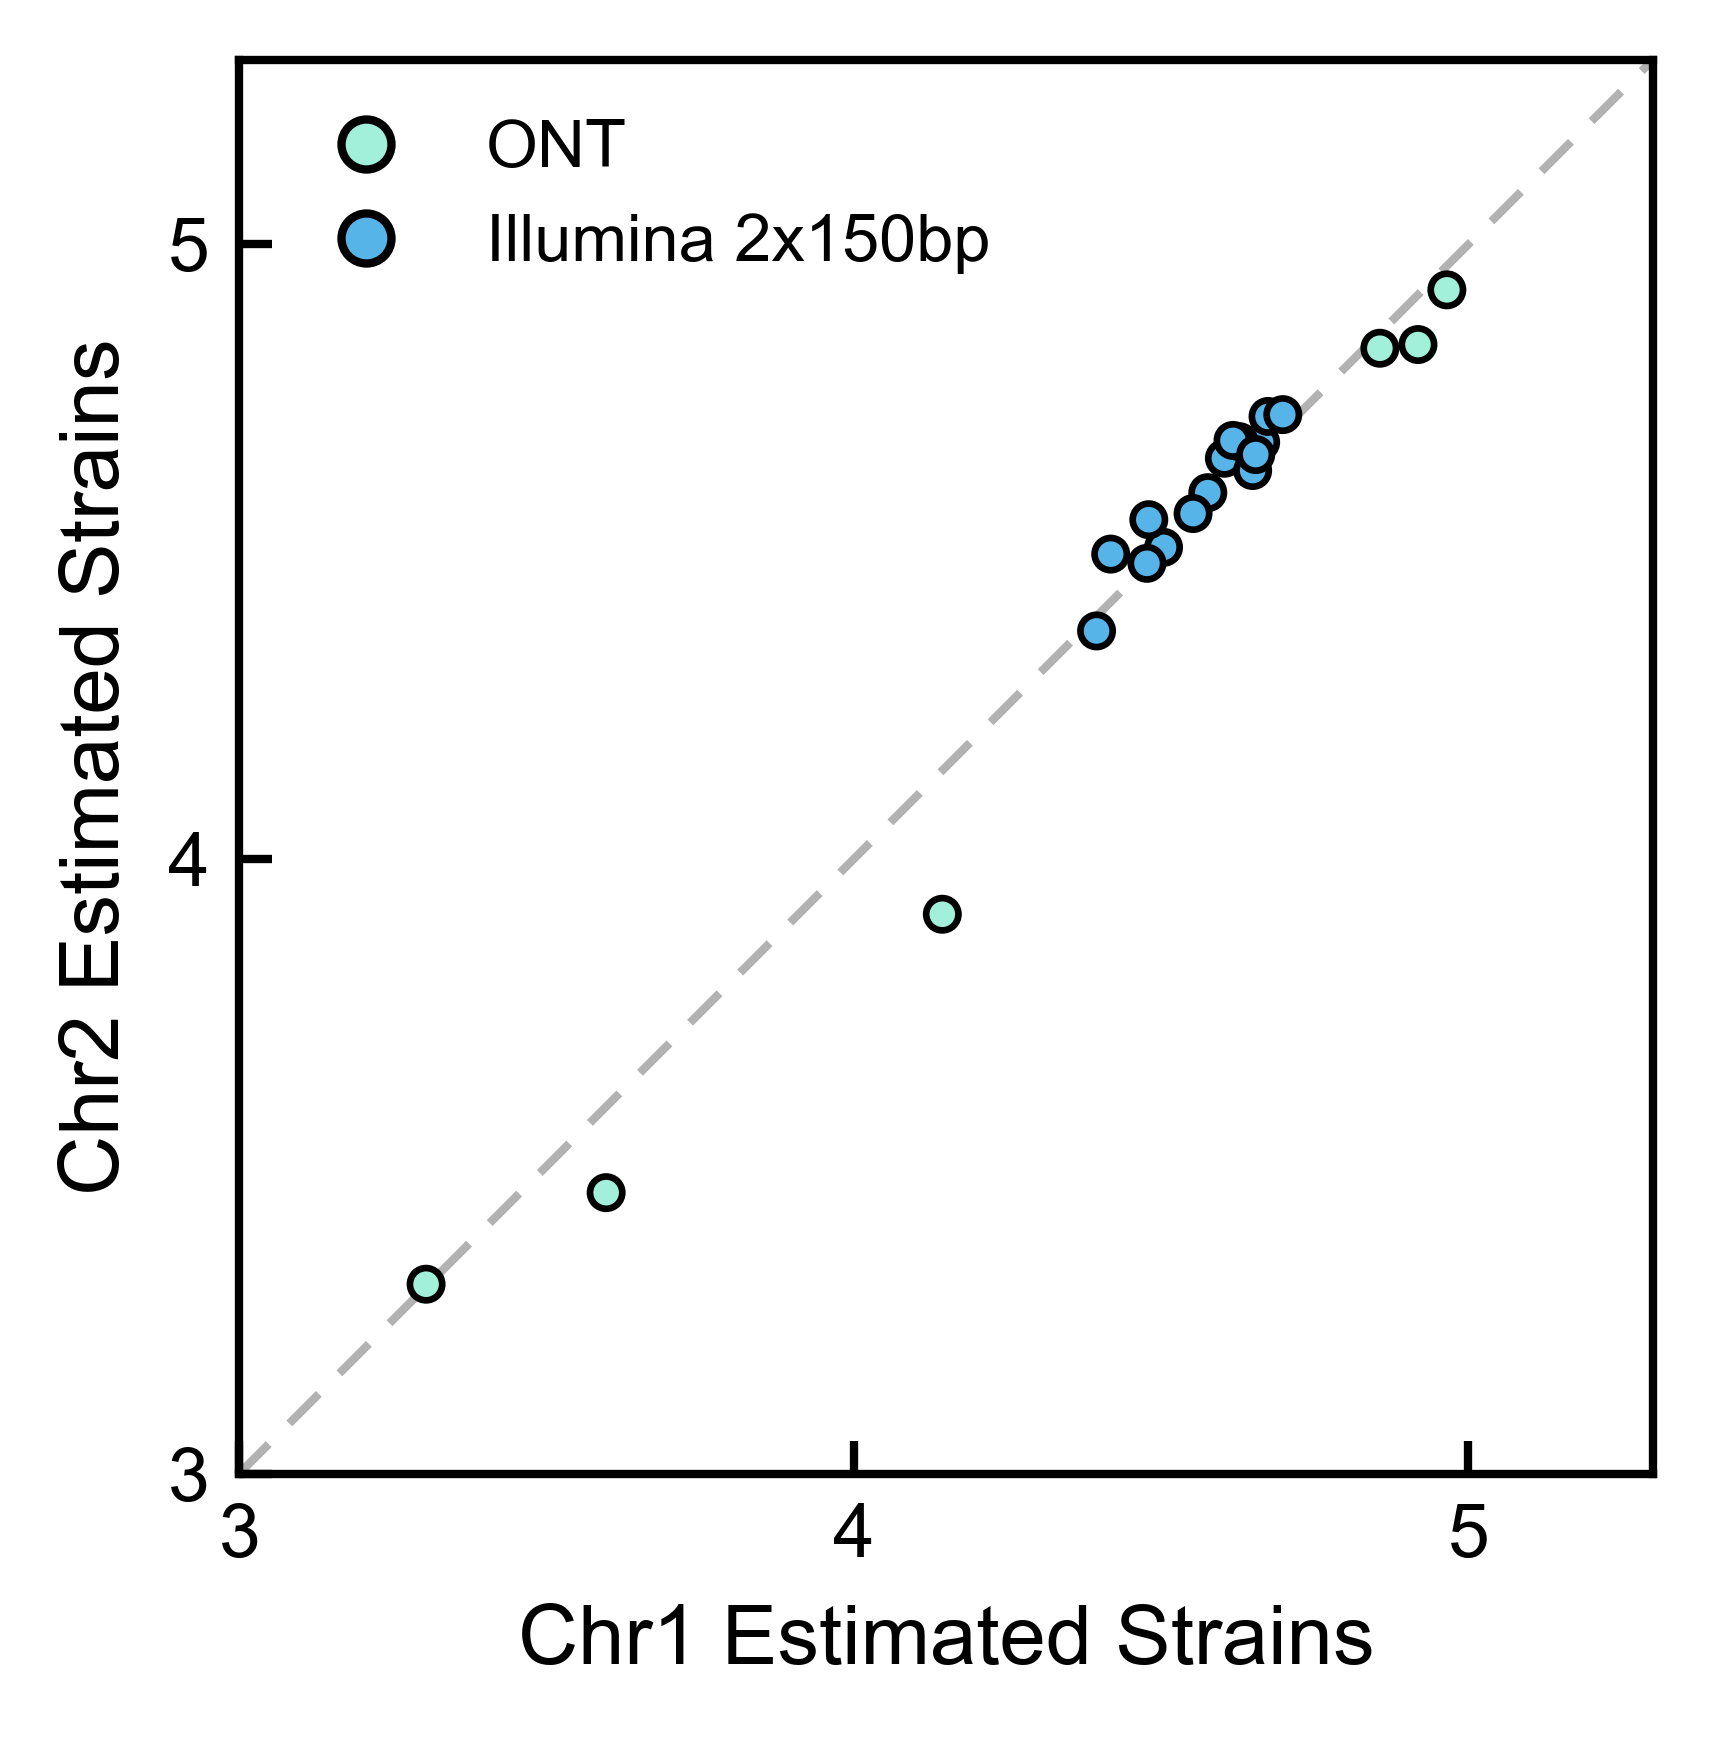

In [30]:
df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure4A_SourceData.csv",index=False)

x = df["Chr1_AvgStrainCt"]
y = df["Chr2_AvgStrainCt"]
labels = df["barcode"]

# Check actual read_type values
print(df["read_type"].unique())

# Color points by read type
color_map = {
    "ONT": "#a2f0d9",
    "Illumina 2x150bp": "#56B4E9",
}

colors = df["read_type"].map(color_map).fillna("#4d4d4d").tolist()

# Plot
fig, ax = plt.subplots(figsize=(3, 3), dpi=600)

ax.scatter(
    x,
    y,
    s=15,
    c=colors,
    edgecolors="black",
    linewidths=0.8,
    zorder=3
)

line, = ax.plot(
    [3, 6],
    [3, 6],
    linewidth=1.0,
    color="black",
    zorder=1,
    alpha=0.3
)
line.set_dashes([5, 3.5])

'''
texts = []
for xi, yi, label in zip(x, y, labels):
    texts.append(
        ax.text(
            xi,
            yi,
            label,
            fontsize=6,
            color="black",
            zorder=4
        )
    )

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.25),
    force_text=(0.8, 1.0),
    force_static=(0.5, 0.5),
    arrowprops=dict(
        arrowstyle="-",
        color="black",
        lw=0.5
    )
)
'''

# Legend only for read types actually present
from matplotlib.lines import Line2D

present_types = df["read_type"].dropna().unique()

legend_elements = []
for read_type in present_types:
    legend_elements.append(
        Line2D(
            [0], [0],
            marker="o",
            linestyle="",
            markerfacecolor=color_map.get(read_type, "#4d4d4d"),
            markeredgecolor="black",
            markersize=6,
            label=read_type
        )
    )

ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=8,
    loc="upper left"
)

ax.set_xlabel("Chr1 Estimated Strains", fontsize=10)
ax.set_ylabel("Chr2 Estimated Strains", fontsize=10)

ax.set_xlim(3, 5.3)
ax.set_ylim(3, 5.3)

ax.set_xticks([3, 4, 5])
ax.set_yticks([3, 4, 5])

for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    labelsize=9,
    width=1,
    length=4,
    color="black",
    direction="in"
)

ax.set_aspect("equal", adjustable="box")

plt.tight_layout()

plt.savefig(
    "XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure4A.pdf",
    dpi=600
)

plt.show()

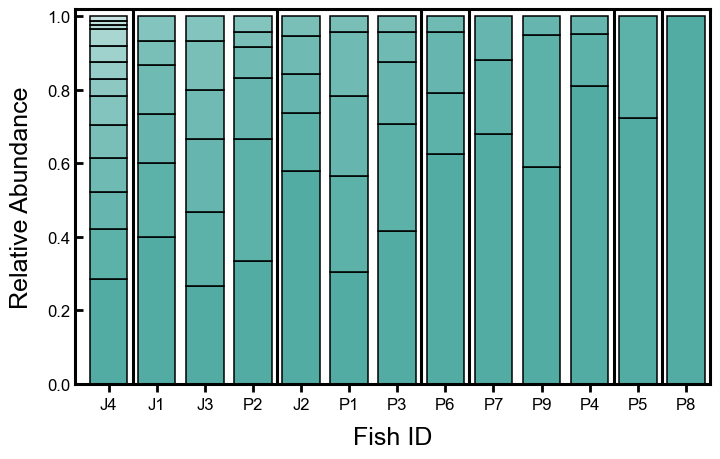

In [31]:
#Relative abundance from Gould et al 2023, ISME paper
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 2.2,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

input_tsv = "XXXXX/AdaptiveSequencing/StrainAbundance/strainAbundanceRations-OUTPUT.tsv"
output_plot = "XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure4B.pdf"
base_color = "#49A89F"
figsize = (7.2, 4.6) 

df = pd.read_csv(input_tsv, sep="\t")
df.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure4B_SourceData.csv",index=False)

fish_col = df.columns[0]
abundance_col = df.columns[-1]
df[abundance_col] = pd.to_numeric(df[abundance_col], errors="coerce")
df = df.dropna(subset=[abundance_col]).copy()

ranked = {}
for fish_id, group in df.groupby(fish_col, sort=False):
    abundances = sorted(group[abundance_col].tolist(), reverse=True)
    ranked[fish_id] = abundances
max_ranks = max(len(v) for v in ranked.values())

def alpha_for_rank(rank_idx, max_ranks):
    """
    Darkest = highest abundance rank
    Lightest = lowest abundance rank
    """
    if max_ranks <= 1:
        return 0.95
    alpha_max = 0.95
    alpha_min = 0.30
    frac = rank_idx / (max_ranks - 1)
    return alpha_max - frac * (alpha_max - alpha_min)

fish_stats = {}
for fish, vals in ranked.items():
    fish_stats[fish] = {
        "n_strains": len(vals),
        "min_abundance": min(vals)
    }

fish_ids = sorted(
    ranked.keys(),
    key=lambda x: (
        -fish_stats[x]["n_strains"],       
        -fish_stats[x]["min_abundance"]   
    )
)

#plot
fig, ax = plt.subplots(figsize=figsize)

x_positions = range(len(fish_ids))
bar_width = 0.78

for x, fish_id in zip(x_positions, fish_ids):
    bottom = 0
    for rank_idx, abundance in enumerate(ranked[fish_id]):
        rgba = list(mcolors.to_rgba(base_color))
        rgba[3] = alpha_for_rank(rank_idx, max_ranks)
        ax.bar(
            x,
            abundance,
            width=bar_width,
            bottom=bottom,
            color=rgba,            
            edgecolor="black",  
            linewidth=1.1
        )
        bottom += abundance

prev_n = None
for i, fish in enumerate(fish_ids):
    n = fish_stats[fish]["n_strains"]
    if prev_n is not None and n != prev_n:
        ax.axvline(i - 0.5, color="black", linewidth=2.2)  # thicker separator
    prev_n = n

ax.set_xticks(list(x_positions))
ax.set_xticklabels(fish_ids, rotation=0, ha="center")
ax.set_xlabel("Fish ID", labelpad=10)
ax.set_ylabel("Relative Abundance", labelpad=10)
ax.set_ylim(0, 1.02)
ax.set_xlim(-0.7, len(fish_ids) - 0.5)
ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.spines["top"].set_visible(2.2)
ax.spines["right"].set_visible(2.2)
ax.spines["left"].set_linewidth(2.2)
ax.spines["bottom"].set_linewidth(2.2)
ax.tick_params(axis="both", which="major", width=2.0, length=6, direction="in")
ax.tick_params(axis='x', direction='out')
ax.grid(False)

plt.tight_layout(pad=0.6)
plt.savefig(output_plot, dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

Minimum strain fractions for selected scenarios:
  scenario     f_min
0       J1  0.066667
1       P3  0.041667

Plotting table:
  scenario     f_min    barcode   condition  target_strain_coverage  \
0       J1  0.066667  barcode01  NoAdaptive                       5   
1       J1  0.066667  barcode01  NoAdaptive                      10   
2       J1  0.066667  barcode01  NoAdaptive                      20   
3       J1  0.066667  barcode01  NoAdaptive                      30   
4       J1  0.066667  barcode02  NoAdaptive                       5   

   required_bases  required_bases_Gb  
0    2.681768e+09           2.681768  
1    5.363536e+09           5.363536  
2    1.072707e+10          10.727072  
3    1.609061e+10          16.090608  
4    2.234194e+09           2.234194  


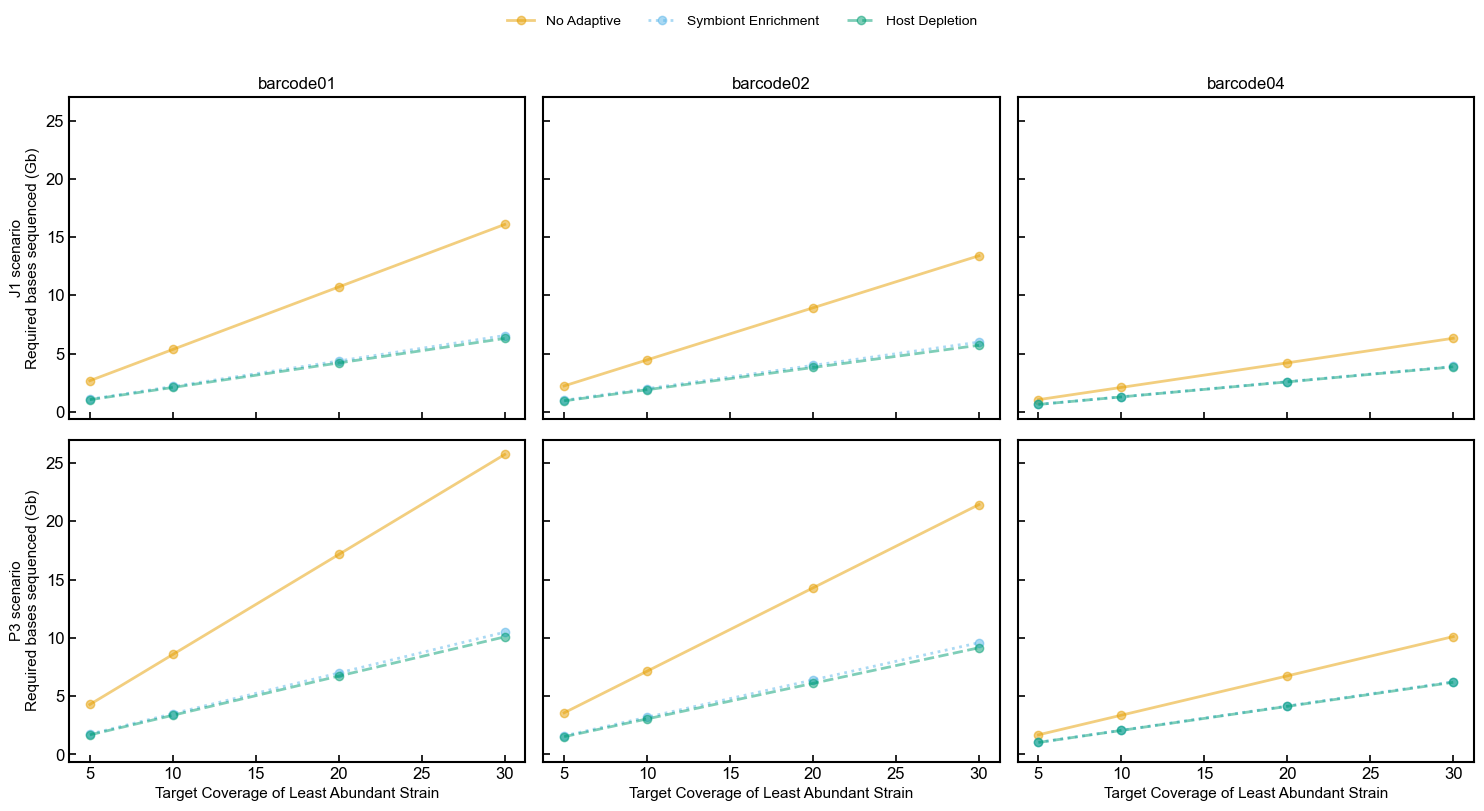

In [32]:
#Anticipated sequencing required at different sequencing depths for different relative abundance scenarios for strain present in the smallest abundance
df_abundance = pd.read_csv("XXXXX/AdaptiveSequencing/StrainAbundance/strainAbundanceRations-OUTPUT.tsv",sep="\t")

scenario_selected = ['J1', 'P3']
df_abundance = df_abundance[df_abundance["Fish ID"].isin(scenario_selected)].copy()
fmin_df = (
    df_abundance
    .groupby("Fish ID")["Abundance"]
    .min()
    .reset_index()
    .rename(columns={"Fish ID": "scenario", "Abundance": "f_min"})
)

print("Minimum strain fractions for selected scenarios:")
print(fmin_df)

df_seqkit = pd.DataFrame({
    "barcode": ["barcode01","barcode02","barcode04",
                "barcode01","barcode02","barcode04",
                "barcode01","barcode02","barcode04"],
    "condition": ["NoAdaptive","NoAdaptive","NoAdaptive",
                  "Pmand-enriched","Pmand-enriched","Pmand-enriched",
                  "Stub-depleted","Stub-depleted","Stub-depleted"],
    "sum_len": [81259430,55307765,56654685,
                81259854,55312486,56656890,
                81259717,55309901,56652050]
})

df_coverage = pd.DataFrame({
    "barcode": ["barcode01","barcode01","barcode01",
                "barcode02","barcode02","barcode02",
                "barcode04","barcode04","barcode04"],
    "condition": ["NoAdaptive","Pmand-enriched","Stub-depleted",
                  "NoAdaptive","Pmand-enriched","Stub-depleted",
                  "NoAdaptive","Pmand-enriched","Stub-depleted"],
    "mean_depth": [2.272552,5.575195,5.796575,
                   1.856635,4.150925,4.348653,
                   4.031790,6.530761,6.584869]
})

condition_rename = {
    "Pmand-enriched": "Pmand_enriched",
    "Stub-depleted": "Stub_depleted"
}
df_seqkit["condition"] = df_seqkit["condition"].replace(condition_rename)
df_coverage["condition"] = df_coverage["condition"].replace(condition_rename)

label_map = {
    "NoAdaptive": "No Adaptive",
    "Pmand_enriched": "Symbiont Enrichment",
    "Stub_depleted": "Host Depletion",
}

condition_color_map = {
    "NoAdaptive": "#E69F00",
    "Pmand_enriched": "#56B4E9",
    "Stub_depleted": "#009E73",
}

condition_linestyle_map = {
    "NoAdaptive": "-",
    "Pmand_enriched": ":",
    "Stub_depleted": "--",
}


df_combined = pd.merge(df_seqkit,df_coverage,on=["barcode", "condition"])
df_combined["coverage_per_base"] = df_combined["mean_depth"] / df_combined["sum_len"]

target_coverages = [5, 10, 20, 30]

results = []
for _, scen_row in fmin_df.iterrows():
    scenario = scen_row["scenario"]
    f_min = scen_row["f_min"]

    for _, r in df_combined.iterrows():
        for target_coverage in target_coverages:
            required_bulk_coverage = target_coverage / f_min
            required_bases = required_bulk_coverage / r["coverage_per_base"]

            results.append({
                "scenario": scenario,
                "f_min": f_min,
                "barcode": r["barcode"],
                "condition": r["condition"],
                "target_strain_coverage": target_coverage,
                "required_bases": required_bases,
                "required_bases_Gb": required_bases / 1e9
            })

df_plot = pd.DataFrame(results)
df_plot.to_csv("XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure4C_SourceData.csv",index=False)

print("\nPlotting table:")
print(df_plot.head())

barcode_label_map = {
    "barcode01": "barcode01",
    "barcode02": "barcode02",
    "barcode04": "barcode04"
}

scenario_order = ["J1", "P3"]
barcode_order = sorted(df_plot["barcode"].unique())
condition_order = ["NoAdaptive", "Pmand_enriched", "Stub_depleted"]

#plot
fig, axes = plt.subplots(
    nrows=len(scenario_order),
    ncols=len(barcode_order),
    figsize=(5 * len(barcode_order), 8),
    sharex=True,
    sharey=True
)

if len(scenario_order) == 1 and len(barcode_order) == 1:
    axes = [[axes]]
elif len(scenario_order) == 1:
    axes = [axes]
elif len(barcode_order) == 1:
    axes = [[ax] for ax in axes]

for i, scenario in enumerate(scenario_order):
    for j, barcode in enumerate(barcode_order):
        ax = axes[i][j]
        sub = df_plot[
            (df_plot["scenario"] == scenario) &
            (df_plot["barcode"] == barcode)
        ]

        for condition in condition_order:
            s = sub[sub["condition"] == condition].sort_values("target_strain_coverage")
            ax.plot(
                s["target_strain_coverage"],
                s["required_bases_Gb"],
                marker="o",
                markersize=6,
                linewidth=2.0,
                color=condition_color_map[condition],
                linestyle=condition_linestyle_map[condition],
                markerfacecolor=condition_color_map[condition],
                alpha=0.5,               
                label=label_map[condition]
            )

        if i == 0:
            ax.set_title(barcode_label_map.get(barcode, barcode), fontsize=12)
            ax.set_xlabel("")
        else:
            ax.set_xlabel("Target Coverage of Least Abundant Strain", fontsize=11)
        if j == 0:
            ax.set_ylabel(f"{scenario} scenario\nRequired bases sequenced (Gb)", fontsize=11)
        ax.tick_params(axis="both",which="both",direction="in",length=5, width=1.2)

        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

        ax.grid(False)

# shared legend
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('XXXXX/AdaptiveSequencing/PaperFigures_IK82/Figure4C.pdf', dpi=1200)
plt.show()

# Figure S1

In [33]:
#Short reads figure for ratio Pmand:Stub - Data from Neff and Gould 2026 - Japan fish only, for fair comparison (NEED TO UPLOAD AND DO THE RATIO BY BASES)
short_read_ratios = pd.read_csv("XXXXX/AdaptiveSequencing/ShortRead/mapped_bases_by_fish_PmandaRatio.tsv", sep = '\t', header =0, index_col=0, usecols=[0,3])
short_read_ratios

,Pmanda_to_Stub_ratio
sample,
SRR35264553,0.257924
SRR35264564,0.215144
SRR35264606,0.277220
SRR35264592,0.204693
SRR35264607,0.130940
SRR35264593,0.212190
SRR35264575,0.293985
SRR35264608,0.374459
SRR35264594,0.230730


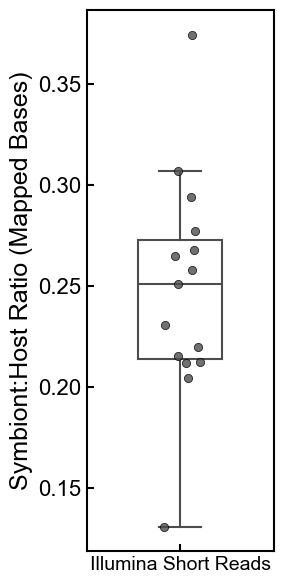

In [34]:
def boxplot_short_reads_only(
    short_read_ratios,
    y="Pmanda_to_Stub_ratio",
    label="Illumina Short Reads",
):

    vals = short_read_ratios[y].dropna().values

    fig, ax = plt.subplots(figsize=(3, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    rng = np.random.default_rng(42)

    col = "#4d4d4d"

    ax.boxplot(
        [vals],
        positions=[0],
        widths=0.45,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(
            facecolor="none",
            edgecolor=col,
            linewidth=1.5,
        ),
        medianprops=dict(
            color=col,
            linewidth=1.5,
        ),
        whiskerprops=dict(
            color=col,
            linewidth=1.5,
        ),
        capprops=dict(
            color=col,
            linewidth=1.5,
        ),
    )

    jitter = (rng.random(len(vals)) - 0.5) * 0.22

    ax.scatter(
        np.full(len(vals), 0) + jitter,
        vals,
        s=35,
        color=col,
        edgecolors="black",
        linewidths=0.6,
        alpha=0.8,
        zorder=10,
    )

    ax.set_xticks([0])
    ax.set_xticklabels([label], fontsize=14)

    ax.set_ylabel(
        "Symbiont:Host Ratio (Mapped Bases)",
        fontsize=18,
    )

    ax.tick_params(
        axis="y",
        direction="in",
        length=5,
        width=1.5,
        labelsize=16,
    )

    ax.tick_params(
        axis="x",
        direction="in",
        length=5,
        width=1.5,
        labelsize=14,
    )

    ax.set_xlim(-0.5, 0.5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    return fig, ax


fig, ax = boxplot_short_reads_only(short_read_ratios)

plt.tight_layout()

plt.savefig(
    "XXXXX/AdaptiveSequencing/PaperFigures_IK82/FigureS1.pdf",
    dpi=1200,
    bbox_inches="tight",
)

plt.show()